In [1]:
import os
import numpy as np
import pylab as pl
import matplotlib as mpl
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt 
import astropy.units as u
import astropy.constants as cc
from astropy.io import fits 
from astropy.cosmology import WMAP9 as cosmo
from astropy.visualization import PowerStretch 
from astropy.visualization.mpl_normalize import ImageNormalize, simple_norm
from astropy.visualization import PercentileInterval 
from scipy import interpolate
from scipy.optimize import curve_fit
mpl.rc('xtick',direction='in') 
from matplotlib.patches import Ellipse
mpl.rc('xtick',direction='in') 
mpl.rc('ytick',direction='in') 
mpl.rcParams['contour.negative_linestyle'] = 'solid' 
plt.rc('font',family='sans-serif',serif='Helvetica',size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 
mpl.rcParams['figure.dpi'] = 150
mpl.rc('xtick',direction='in') 
mpl.rc('xtick',direction='in') 
mpl.rc('ytick',direction='in') 
pl.rcParams["xtick.minor.visible"] =  True
pl.rcParams["ytick.minor.visible"] =  True
mpl.rcParams['font.size'] = 12
mpl.rcParams['xtick.labelsize'] = 12  
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.family'] = 'serif'
#plt.rc('font',family='sans-serif',serif='Helvetica',size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 


In [2]:
from astropy.io import fits
from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats
import numpy as np
from regions import PixCoord, CirclePixelRegion

# Load image
filename = 'data/full_eband/tm0_soft_band_8_23eV.fits'
data = fits.getdata(filename)
header = fits.getheader(filename)

# Check data properties
print("Data statistics:")
print(f"  Min: {np.min(data):.6f}")
print(f"  Max: {np.max(data):.6f}")
print(f"  Mean: {np.mean(data):.6f}")
print(f"  Data type: {data.dtype}")

# Handle negative values and zeros (common in X-ray images)
# Set a floor value to avoid issues
data_clean = np.copy(data)
data_clean[data_clean < 0] = 0

# Calculate background more robustly
mean, median, std = sigma_clipped_stats(data_clean, sigma=3.0, maxiters=10)
print(f"\nBackground (sigma-clipped):")
print(f"  Mean: {mean:.6f}")
print(f"  Median: {median:.6f}")
print(f"  Std: {std:.6f}")

# More stringent detection criteria
# Increase threshold significantly to reduce false detections
threshold = 10 * std  # 10-sigma detection (was 5-sigma)

print(f"\nDetection threshold: {threshold:.6f}")

# DAOStarFinder with stricter parameters
daofind = DAOStarFinder(
    fwhm=3.5,                    # Expected FWHM in pixels
    threshold=threshold,          # 10-sigma threshold
    sharplo=0.3, sharphi=0.9,    # Stricter sharpness limits (avoid extended sources)
    roundlo=-0.5, roundhi=0.5,   # Stricter roundness (point sources should be round)
    brightest=500,               # Only keep brightest 500 sources
    exclude_border=True          # Ignore edge sources
)

sources = daofind(data_clean - median)

if sources is None or len(sources) == 0:
    print("\nNo sources detected with current parameters.")
    print("Try lowering threshold or adjusting FWHM.")
else:
    print(f"\nDetected {len(sources)} sources")
    
    # Show some statistics about detected sources
    print(f"\nSource properties:")
    print(f"  Peak flux range: {sources['peak'].min():.3f} to {sources['peak'].max():.3f}")
    print(f"  Sharpness range: {sources['sharpness'].min():.3f} to {sources['sharpness'].max():.3f}")
    print(f"  Roundness range: {sources['roundness1'].min():.3f} to {sources['roundness1'].max():.3f}")
    
    # Sort by brightness
    sources.sort('peak')
    sources.reverse()
    
    print(f"\nTop 10 brightest sources:")
    print(sources['xcentroid', 'ycentroid', 'peak', 'sharpness'][:10])
    
    # Create cheese mask with appropriate radius
    mask = np.zeros_like(data_clean, dtype=bool)
    mask_radius = 10.0  # pixels - adjust based on PSF
    
    for source in sources:
        x, y = source['xcentroid'], source['ycentroid']
        center = PixCoord(x, y)
        region = CirclePixelRegion(center, mask_radius)
        mask_region = region.to_mask().to_image(data.shape)
        if mask_region is not None:
            mask |= (mask_region > 0)
    
    # Save outputs
    sources.write('point_sources_catalog.fits', overwrite=True)
    fits.writeto('cheese_mask.fits', mask.astype(np.uint8), 
                 header=header, overwrite=True)
    
    # Also create DS9 region file
    with open('point_sources.reg', 'w') as f:
        f.write('# Region file format: DS9 version 4.1\n')
        f.write('physical\n')
        for source in sources:
            x, y = source['xcentroid'], source['ycentroid']
            flux = source['peak']
            f.write(f'circle({x:.2f},{y:.2f},{mask_radius}) # color=red text={{{flux:.2f}}}\n')
    
    pct_masked = 100.0 * mask.sum() / mask.size
    print(f"\nMasked {mask.sum()} pixels ({pct_masked:.2f}% of image)")
    print("\nSaved:")
    print("  - point_sources_catalog.fits")
    print("  - cheese_mask.fits")
    print("  - point_sources.reg")

Data statistics:
  Min: 0.000000
  Max: 86.000000
  Mean: 0.104831
  Data type: >i4

Background (sigma-clipped):
  Mean: 0.000000
  Median: 0.000000
  Std: 0.000000

Detection threshold: 0.000000

Detected 500 sources

Source properties:
  Peak flux range: 1.000 to 86.000
  Sharpness range: 0.302 to 0.900
  Roundness range: -0.498 to 0.499

Top 10 brightest sources:
    xcentroid          ycentroid      peak      sharpness     
------------------ ------------------ ---- -------------------
333.18166905240474 465.39217473846713 86.0  0.6143209890095995
 682.0723034387779 425.91981656999695 58.0 0.38516459061080116
 618.7797328986485  419.2918083793662 31.0 0.36285705637090176
 673.2101428982547  714.3441869821431 28.0  0.5983645007635194
 683.0579273795702  574.2921212430246 27.0 0.35264474107346877
 760.6516079871341  585.3461310410428 27.0  0.5659759389699486
 342.8219084927359  580.6135527748661 23.0  0.7862381019837755
 549.9876892193129  690.8254461805177 20.0   0.386366624110913
 

light curve filtering and gaussian fitting
total number of bins: 504
rate range (all data): 0.6302 to 1.1402
mean rate (all data): 0.8408

exclud. interval 6.241225e+08 to 6.241243e+08: 19 bins
exclud. interval 6.241265e+08 to 6.241282e+08: 18 bins
exclud. interval 6.241540e+08 to 6.241579e+08: 40 bins
exclud. interval 6.241328e+08 to 6.241338e+08: 11 bins

bins after filtering: 416 / 504 (82.5%)
rate range (filtered): 0.6436 to 1.0120
mean rate (filtered): 0.8253
std dev (filtered): 0.0622



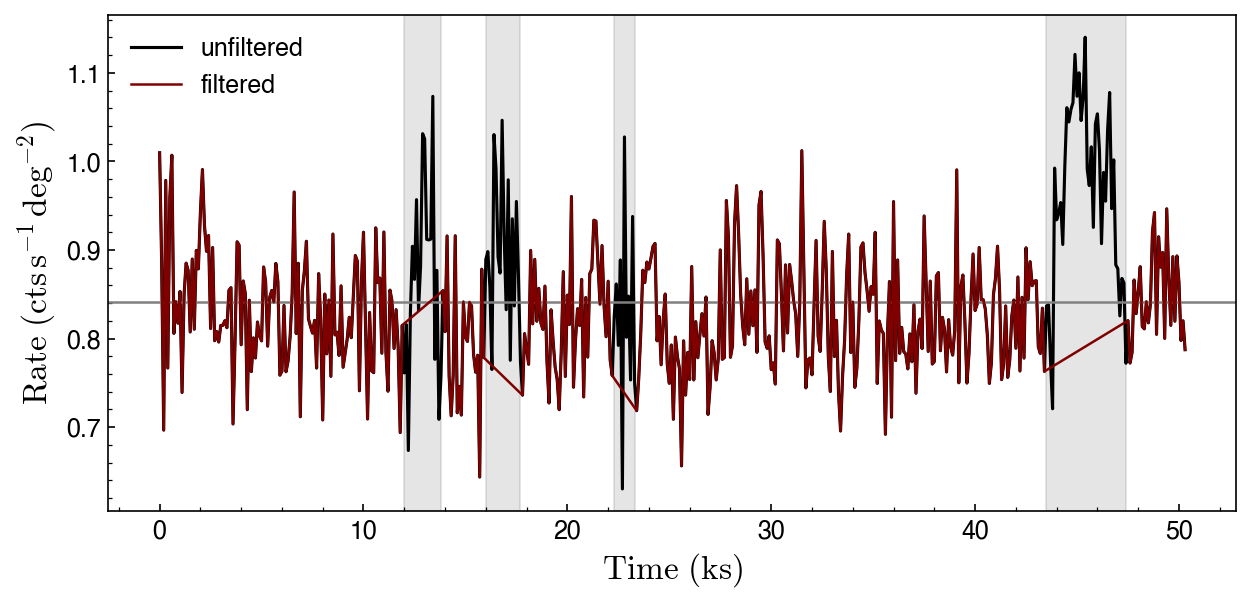

fit results (on filtered data):
Mean (μ):              0.818501
Std Dev (σ):           0.063073
3-sigma threshold:     1.007721
Range: μ ± 3σ:         [0.629281, 1.007721]

SUMMARY FOR NEXT STEPS:
Use this threshold value in flaregti:
  threshold=1.007721

Or use the custom GTI file approach with the bad_intervals defined above.


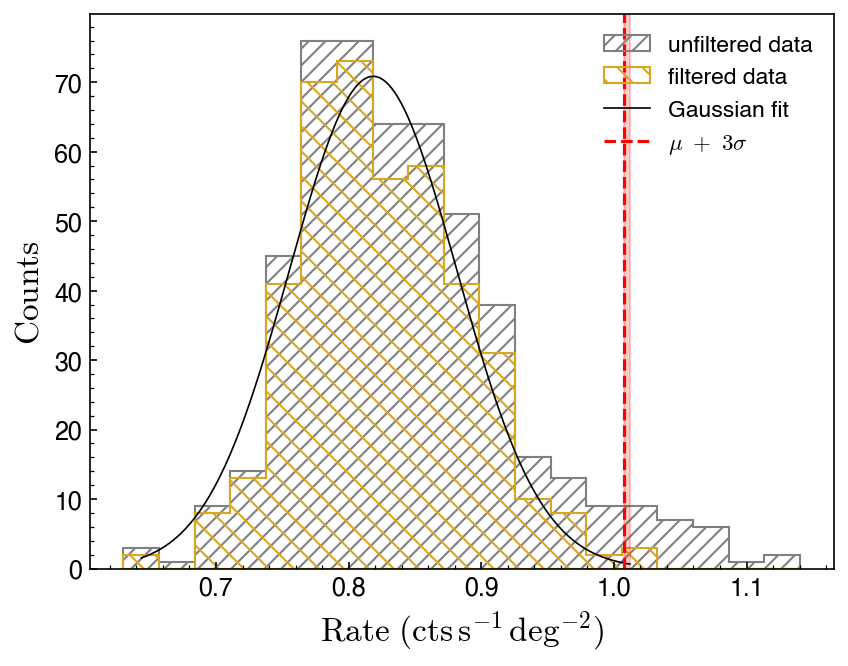

In [22]:

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy import stats


def gaussian(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

light_curve = fits.open('data/full_eband/light_curves/tm0_light_curve.fits')

time_actual = light_curve[1].data['TIME']
rate = light_curve[1].data['RATE']

print("="*70)
print("light curve filtering and gaussian fitting")
print("="*70)
print(f"total number of bins: {len(rate)}")
print(f"rate range (all data): {rate.min():.4f} to {rate.max():.4f}")
print(f"mean rate (all data): {np.mean(rate):.4f}")
print()

# flare intervals to exclude (in seconds)
bad_intervals = [
    (6.241225026425600e+08, 6.241243026425600e+08),
    (6.241265026425600e+08, 6.241282026425600e+08),
    (6.241540026425600e+08, 6.241579026425600e+08),
    (6.241328026425600e+08, 6.241338026425600e+08),
]

# mask for gtis
good_mask = np.ones(len(time_actual), dtype=bool)

for bad_start, bad_stop in bad_intervals:
    bad_mask = (time_actual >= bad_start) & (time_actual <= bad_stop)
    good_mask &= ~bad_mask
    n_bad = np.sum(bad_mask)
    print(f"exclud. interval {bad_start:.6e} to {bad_stop:.6e}: {n_bad} bins")

# filtered data
rate_filtered = rate[good_mask]

print()
print(f"bins after filtering: {len(rate_filtered)} / {len(rate)} ({100*len(rate_filtered)/len(rate):.1f}%)")
print(f"rate range (filtered): {rate_filtered.min():.4f} to {rate_filtered.max():.4f}")
print(f"mean rate (filtered): {np.mean(rate_filtered):.4f}")
print(f"std dev (filtered): {np.std(rate_filtered):.4f}")
print()

# hist

time_ks = (time_actual - time_actual[0]) / 1000.0
# ax1.plot(time_ks, rate, 'k-', linewidth=0.8, alpha=0.5, label='All data')
# ax1.plot(time_ks[good_mask], rate[good_mask], 'b-', linewidth=0.8, label='Filtered data')

pl.plot(time_ks, rate, 'k-', label='unfiltered')
pl.axhline(np.mean(rate), color='grey', linestyle='-', linewidth=1.2)
pl.xlabel(r'$\rm Time\ (ks)$', fontsize=16)
pl.ylabel(r'$\rm Rate\ (cts\,s^{-1}\,deg^{-2})$', fontsize=16)
pl.subplots_adjust(right=1.3, top=.8)
pl.plot(time_ks[good_mask], rate[good_mask], color = 'maroon', ls='-', label='filtered', linewidth=1.2)


# shade bad intervals
for bad_start, bad_stop in bad_intervals:
    bad_start_ks = (bad_start - time_actual[0]) / 1000.0
    bad_stop_ks = (bad_stop - time_actual[0]) / 1000.0
    pl.axvspan(bad_start_ks, bad_stop_ks, alpha=0.2, color='grey')
pl.legend(frameon=False, fontsize=12)
pl.show()

n_bins = np.linspace(np.min(rate), np.max(rate), 20)
counts_all, bins_all, _ = pl.hist(rate, bins=n_bins, histtype='stepfilled',
            fill=False, edgecolor='grey', hatch='///', label='unfiltered data')
# pl.axvline(np.mean(rate), color='red', linestyle='--', linewidth=2, 
#             label=f'Mean = {np.mean(rate):.4f}')
pl.xlabel(r'$\rm Rate\ (cts\,s^{-1}\,deg^{-2})$', fontsize=16)
pl.ylabel(r'$\rm Counts$', fontsize=16)
pl.legend(frameon=False, fontsize=12)

counts, bins, patches = pl.hist(rate_filtered, bins=n_bins,histtype='stepfilled',
            fill=False, edgecolor='goldenrod', hatch='\\\\', label='filtered data')

# fit Gaussian to filtered data histogram
bin_centers = (bins[:-1] + bins[1:]) / 2

amp_guess = counts.max()
mean_guess = np.mean(rate_filtered)
sigma_guess = np.std(rate_filtered)

try:
    # fit Gaussian
    popt, pcov = curve_fit(gaussian, bin_centers, counts, 
                          p0=[amp_guess, mean_guess, sigma_guess])
    
    amp_fit, mean_fit, sigma_fit = popt
    
    # Plot fitted Gaussian
    x_fit = np.linspace(rate_filtered.min(), rate_filtered.max(), 200)
    y_fit = gaussian(x_fit, amp_fit, mean_fit, sigma_fit)
    pl.plot(x_fit, y_fit, ls='-', color='k', linewidth=0.8, label='Gaussian fit')
    
    threshold_3sigma = mean_fit + 3 * sigma_fit
    
    # pl.axvline(mean_fit, color='green', linestyle='--', linewidth=2, 
    #             label=f'μ = {mean_fit:.4f}')
    pl.axvline(threshold_3sigma, color='red', linestyle='--', linewidth=1.5, 
                label=r'$\rm \mu\ +\ 3\sigma$')
    
    pl.axvspan(threshold_3sigma, rate_filtered.max(), alpha=0.2, color='red')
    
    print("="*70)
    print("fit results (on filtered data):")
    print("="*70)
    print(f"Mean (μ):              {mean_fit:.6f}")
    print(f"Std Dev (σ):           {sigma_fit:.6f}")
    print(f"3-sigma threshold:     {threshold_3sigma:.6f}")
    print(f"Range: μ ± 3σ:         [{mean_fit - 3*sigma_fit:.6f}, {threshold_3sigma:.6f}]")
    print("="*70)
    
except Exception as e:
    print(f"warning: Gaussian fit failed: {e}")
    threshold_3sigma = np.mean(rate_filtered) + 3 * np.std(rate_filtered)
    print(f"using simple calculation: μ + 3σ = {threshold_3sigma:.6f}")

pl.xlabel(r'$\rm Rate\ (cts\,s^{-1}\,deg^{-2})$', fontsize=16)
pl.ylabel(r'$\rm Counts$', fontsize=16)
pl.legend(frameon=False, fontsize=11)


light_curve.close()

print()
print("="*70)
print("SUMMARY FOR NEXT STEPS:")
print("="*70)
print(f"Use this threshold value in flaregti:")
print(f"  threshold={threshold_3sigma:.6f}")
print()
print("Or use the custom GTI file approach with the bad_intervals defined above.")
print("="*70)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]
 [astropy.io.fits.verify]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1996/03/13' to '1996-03-13''. [astropy.wcs.wcs]


selected 50 bright optical sources

 optical source coordinates:
source 1: RA=107.882985°, Dec=-49.425895°
source 2: RA=107.703762°, Dec=-48.933365°
source 3: RA=107.882386°, Dec=-49.427111°
source 4: RA=107.697586°, Dec=-48.924324°
source 5: RA=107.880482°, Dec=-49.425655°
source 6: RA=107.881802°, Dec=-49.426643°
source 7: RA=107.883443°, Dec=-49.423790°
source 8: RA=106.980612°, Dec=-48.917936°
source 9: RA=107.674150°, Dec=-48.933869°
source 10: RA=106.983220°, Dec=-48.917754°
source 11: RA=107.884548°, Dec=-49.426506°
source 12: RA=107.031167°, Dec=-49.118242°
source 13: RA=107.693492°, Dec=-48.925988°
source 14: RA=107.123474°, Dec=-49.214137°
source 15: RA=107.673806°, Dec=-48.933322°
source 16: RA=106.419045°, Dec=-48.839725°
source 17: RA=107.246066°, Dec=-48.947800°
source 18: RA=106.668887°, Dec=-49.233938°
source 19: RA=107.730746°, Dec=-49.439730°
source 20: RA=107.731881°, Dec=-49.440621°
source 21: RA=107.878142°, Dec=-49.423637°
source 22: RA=106.975416°, Dec=-48.726610

this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1996/03/13' to '1996-03-13''. [astropy.wcs.wcs]


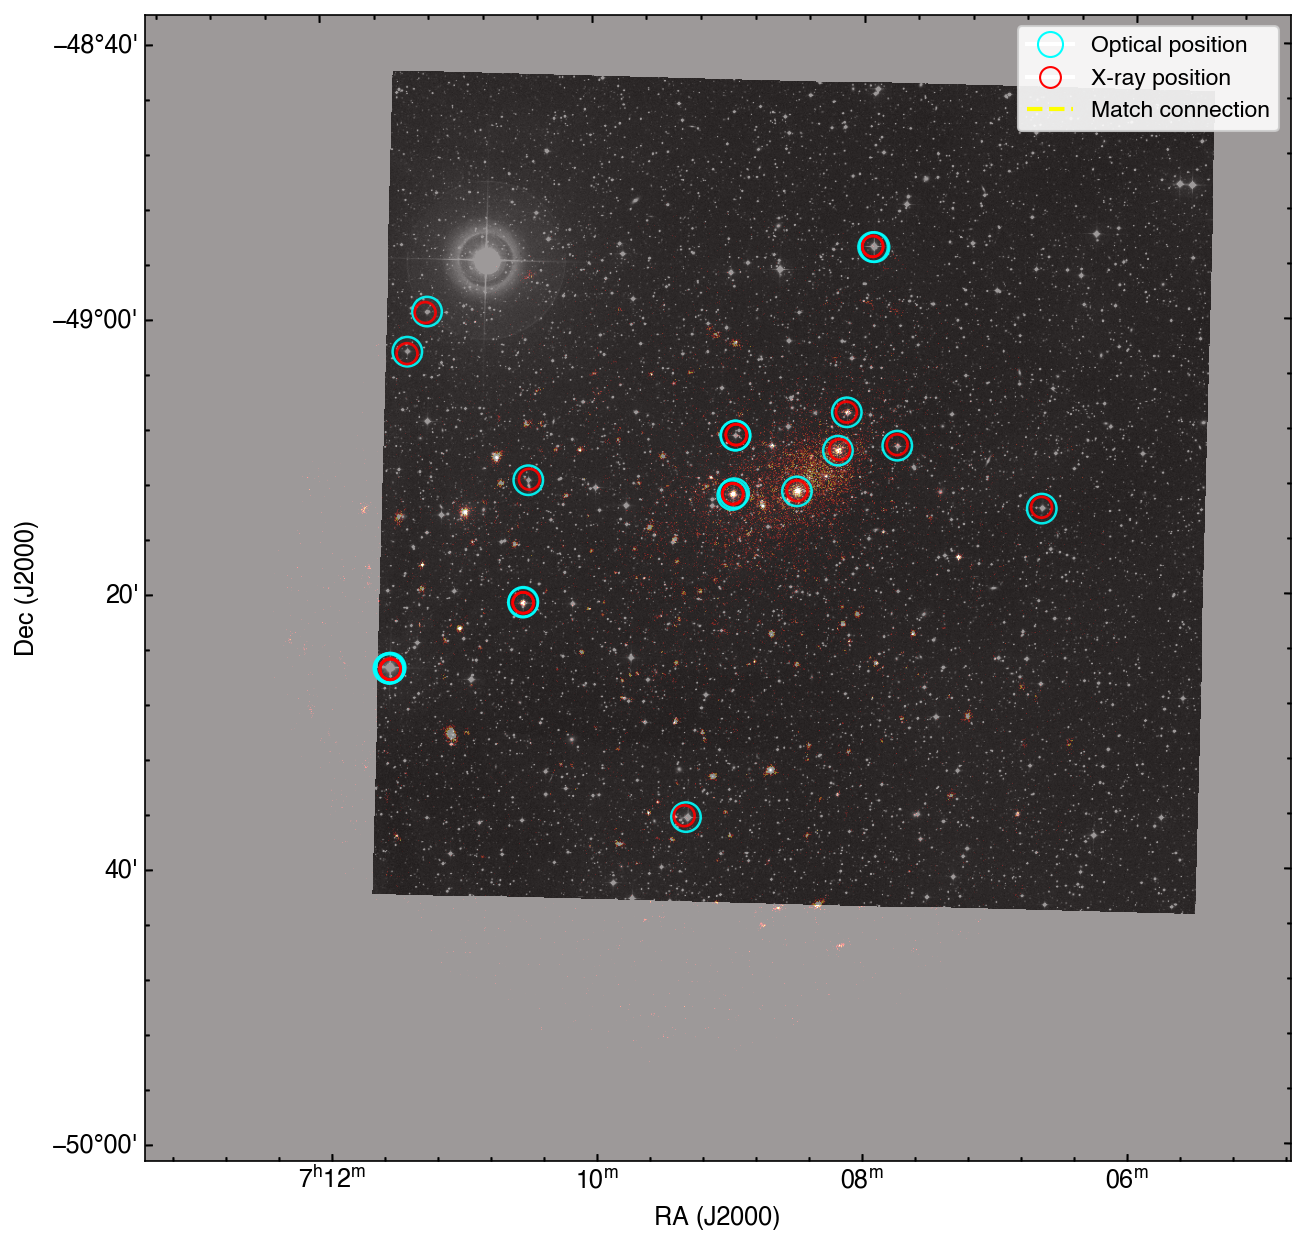

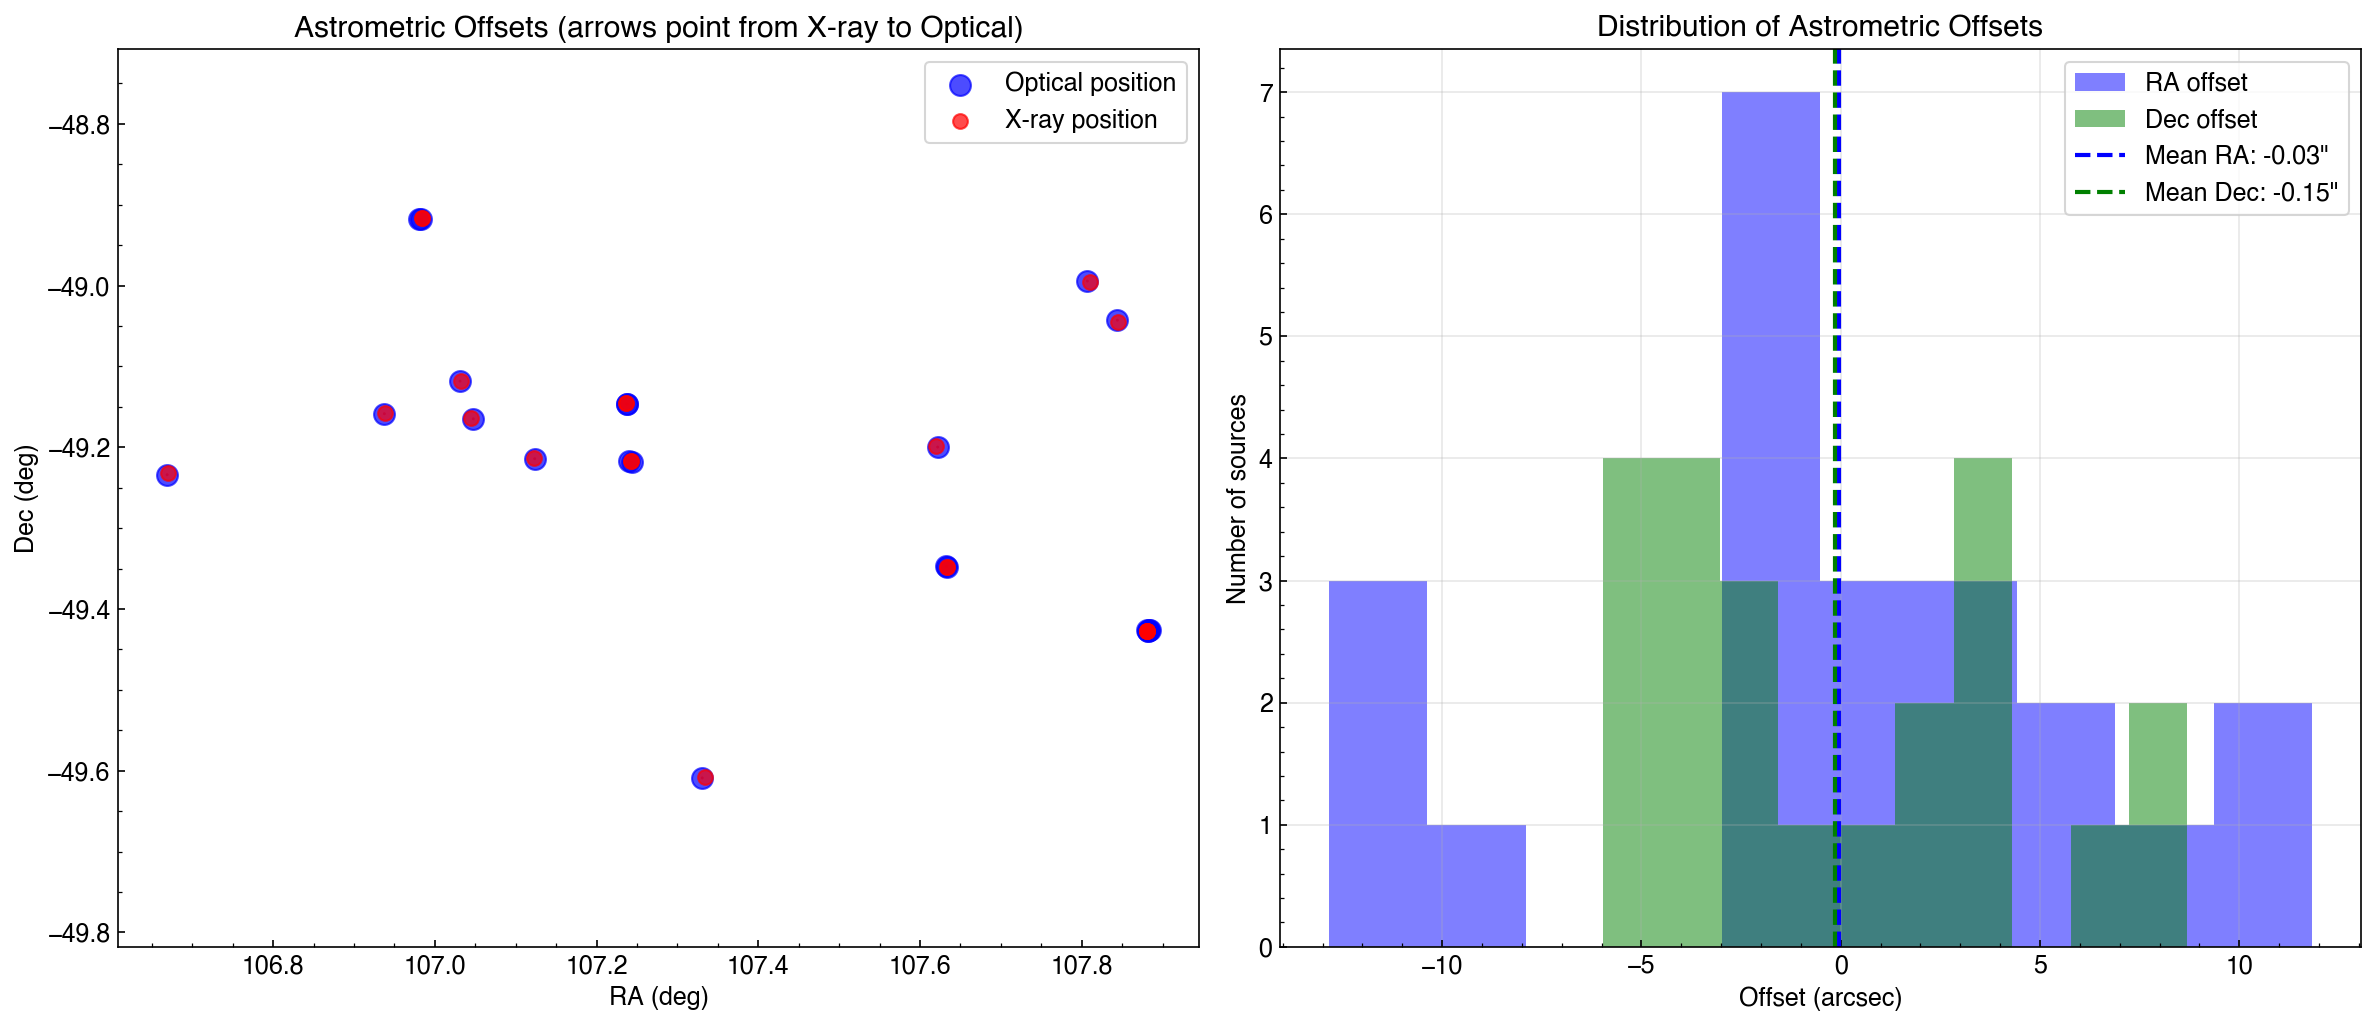

In [6]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from reproject import reproject_interp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from astropy.table import Table

xray = fits.open('data/full_eband/tm0_soft_band_8_23eV.fits')
optical = fits.open('data/full_eband/dss2red.fits')

xray_wcs = WCS(xray[0].header)
optical_wcs = WCS(optical[0].header)
xray_data = xray[0].data
optical_data = optical[0].data

# detect optical sources to serve as a reference 

mean, median, std = sigma_clipped_stats(optical_data, sigma=3.0)
daofind_optical = DAOStarFinder(fwhm=5.0, threshold=5.*std)
optical_sources = daofind_optical(optical_data - median)

# sort by flux and take brightest 15-20 sources (easier to identify in X-ray)
optical_sources.sort('flux')
optical_sources.reverse()
n_sources = min(50, len(optical_sources))
bright_optical = optical_sources[:n_sources]

print(f"selected {n_sources} bright optical sources")

# convert optical source positions to RA/Dec

optical_coords = optical_wcs.pixel_to_world(
    bright_optical['xcentroid'], 
    bright_optical['ycentroid']
)

print("\n optical source coordinates:")
for i, coord in enumerate(optical_coords):
    print(f"source {i+1}: RA={coord.ra.deg:.6f}°, Dec={coord.dec.deg:.6f}°")

# deteect X-ray sources
mean, median, std = sigma_clipped_stats(xray_data, sigma=3.0)
daofind_xray = DAOStarFinder(fwhm=3.0, threshold=3.*std)
xray_sources = daofind_xray(xray_data - median)

if xray_sources is None or len(xray_sources) == 0:
    print("No X-ray sources detected - try lowering threshold")
else:
    print(f"\nfound {len(xray_sources)} X-ray sources")
    
    # convert pixels to ra/dec

    xray_coords = xray_wcs.pixel_to_world(
        xray_sources['xcentroid'], 
        xray_sources['ycentroid']
    )
    
    # cross-match X-ray/optical sources
    idx, d2d, d3d = optical_coords.match_to_catalog_sky(xray_coords)
    
    # analyze offsets
    match_radius = 10 * u.arcsec
    matches = d2d < match_radius
    
    print(f"\n{np.sum(matches)} sources matched within {match_radius}")
    
    if np.sum(matches) > 3:
        # calculate ra and dec offsets
        matched_optical = optical_coords[matches]
        matched_xray = xray_coords[idx[matches]]
        
        # offset = optical - xray pos
        ra_offset = (matched_optical.ra - matched_xray.ra).to(u.arcsec)
        dec_offset = (matched_optical.dec - matched_xray.dec).to(u.arcsec)
        
        # stats - simple mean/median/stddev
        mean_ra_offset = np.mean(ra_offset.value)
        mean_dec_offset = np.mean(dec_offset.value)
        median_ra_offset = np.median(ra_offset.value)
        median_dec_offset = np.median(dec_offset.value)
        std_ra_offset = np.std(ra_offset.value)
        std_dec_offset = np.std(dec_offset.value)
        
        print("\n" + "="*60)
        print("astrometric offset results:")
        print("="*60)
        print(f"mean RA offset:    {mean_ra_offset:+.2f} ± {std_ra_offset:.2f} arcsec")
        print(f"mean Dec offset:   {mean_dec_offset:+.2f} ± {std_dec_offset:.2f} arcsec")
        print(f"median RA offset:  {median_ra_offset:+.2f} arcsec")
        print(f"median Dec offset: {median_dec_offset:+.2f} arcsec")
        
        total_offset = np.sqrt(mean_ra_offset**2 + mean_dec_offset**2)

        print(f"\ntotal systematic offset: {total_offset:.2f} arcsec")
        print("="*60)
        
        # write to a table
        match_table = Table()
        match_table['source_id'] = np.arange(1, np.sum(matches)+1)
        match_table['optical_ra'] = matched_optical.ra.deg
        match_table['optical_dec'] = matched_optical.dec.deg
        match_table['xray_ra'] = matched_xray.ra.deg
        match_table['xray_dec'] = matched_xray.dec.deg
        match_table['ra_offset_arcsec'] = ra_offset.value
        match_table['dec_offset_arcsec'] = dec_offset.value
        match_table['separation_arcsec'] = d2d[matches].to(u.arcsec).value
        
        match_table.write('astrometry_matches.csv', overwrite=True)
        print("\n detailed matches saved to: astrometry_matches.csv")
        
        # overlay plot with marked
        print("\nCreating overlay image...")
        
        # reproject optical to X-ray WCS
        optical_reproj, footprint = reproject_interp(
            optical, 
            xray_wcs, 
            shape_out=xray_data.shape
        )
        
        fig = plt.figure(figsize=(12, 9))
        ax = plt.subplot(projection=xray_wcs)
        
        # show optical as grayscale background
        optical_vmin = np.percentile(optical_reproj[~np.isnan(optical_reproj)], 1)
        optical_vmax = np.percentile(optical_reproj[~np.isnan(optical_reproj)], 99)
        ax.imshow(optical_reproj, cmap='gray', origin='lower', 
                  vmin=optical_vmin, vmax=optical_vmax, alpha=0.8)
        
        # overlay X-ray as semi-transparent colored image
        xray_vmin = np.percentile(xray_data[xray_data > 0], 10)
        xray_vmax = np.percentile(xray_data[xray_data > 0], 99)
        ax.imshow(xray_data, cmap='hot', origin='lower', alpha=0.4,
                  vmin=xray_vmin, vmax=xray_vmax)
        
        # markers for matched sources
        for i, (opt_coord, xray_coord) in enumerate(zip(matched_optical, matched_xray)):
            # optical source - blue circle
            ax.scatter(opt_coord.ra.deg, opt_coord.dec.deg, 
                      transform=ax.get_transform('world'),
                      s=200, facecolors='none', edgecolors='cyan', 
                      linewidths=1.2, marker='o', alpha=0.9)
            
            # X-ray source - red circle
            ax.scatter(xray_coord.ra.deg, xray_coord.dec.deg, 
                      transform=ax.get_transform('world'),
                      s=100, facecolors='none', edgecolors='red', 
                      linewidths=1.3, marker='o', alpha=0.9)
            
            # # Draw line connecting matched pairs
            # ax.plot([opt_coord.ra.deg, xray_coord.ra.deg],
            #        [opt_coord.dec.deg, xray_coord.dec.deg],
            #        transform=ax.get_transform('world'),
            #        color='yellow', linewidth=1.5, alpha=0.6, linestyle='--')
            
            # # Add source number label
            # ax.text(opt_coord.ra.deg, opt_coord.dec.deg, f'  {i+1}', 
            #        transform=ax.get_transform('world'),
            #        color='white', fontsize=10, fontweight='bold',
            #        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
        
        #ax.coords.grid(color='white', alpha=0.3, linestyle='--')
        ax.coords[0].set_axislabel('RA (J2000)', fontsize=12)
        ax.coords[1].set_axislabel('Dec (J2000)', fontsize=12)
        
        # # Title with offset info
        # ax.set_title(f'Abell 3408: Optical (gray) + X-ray (hot)\n'
        #             f'Matched Sources (n={np.sum(matches)}) | '
        #             f'Offset: RA={mean_ra_offset:+.2f}" Dec={mean_dec_offset:+.2f}"',
        #             fontsize=14, fontweight='bold', pad=20)
        
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='cyan', markersize=12, linewidth=2,
                   label='Optical position'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='red', markersize=10, linewidth=2,
                   label='X-ray position'),
            Line2D([0], [0], color='yellow', linewidth=2, linestyle='--',
                   label='Match connection')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11,
                 framealpha=0.9)
        
        pl.tight_layout()
        pl.subplots_adjust(top=0.92, right=0.95)
        pl.savefig('overlay_with_matches.pdf', format='pdf', dpi=150, bbox_inches='tight')
        pl.show()
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Left: Quiver plot showing offset vectors
        ax = axes[0]
        ax.quiver(matched_optical.ra.deg, matched_optical.dec.deg,
                  ra_offset.value/3600, dec_offset.value/3600,
                  angles='xy', scale_units='xy', scale=1, 
                  color='red', width=0.003, alpha=0.7)
        ax.scatter(matched_optical.ra.deg, matched_optical.dec.deg, 
                   c='blue', s=100, alpha=0.7, label='Optical position')
        ax.scatter(matched_xray.ra.deg, matched_xray.dec.deg, 
                   c='red', s=50, alpha=0.7, label='X-ray position')
        ax.set_xlabel('RA (deg)')
        ax.set_ylabel('Dec (deg)')
        ax.set_title('Astrometric Offsets (arrows point from X-ray to Optical)')
        ax.legend()
        #ax.grid(True, alpha=0.3)
        ax.axis('equal')
        
        # hist of the offsets
        ax = axes[1]
        ax.hist(ra_offset.value, bins=10, alpha=0.5, label='RA offset', color='blue')
        ax.hist(dec_offset.value, bins=10, alpha=0.5, label='Dec offset', color='green')
        ax.axvline(mean_ra_offset, color='blue', linestyle='--', linewidth=2, 
                   label=f'Mean RA: {mean_ra_offset:.2f}"')
        ax.axvline(mean_dec_offset, color='green', linestyle='--', linewidth=2,
                   label=f'Mean Dec: {mean_dec_offset:.2f}"')
        ax.set_xlabel('Offset (arcsec)')
        ax.set_ylabel('Number of sources')
        ax.set_title('Distribution of Astrometric Offsets')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        pl.tight_layout()
        pl.savefig('astrometry_offset_analysis.pdf', format='pdf', dpi=150, bbox_inches='tight')
        pl.show()
        
    else:
        print("\nNot enough matches found. Try:")
        print("- Increasing match_radius")
        print("- Lowering X-ray detection threshold")
        print("- Checking if images actually overlap")

In [10]:
from astropy.stats import sigma_clip

match_table = Table.read('astrometry_matches.csv')


ra_offsets = match_table['ra_offset_arcsec']
dec_offsets = match_table['dec_offset_arcsec']

ra_clipped = sigma_clip(ra_offsets, sigma=2.5, maxiters=3)
dec_clipped = sigma_clip(dec_offsets, sigma=2.5, maxiters=3)

good_sources = ~ra_clipped.mask & ~dec_clipped.mask
n_good = np.sum(good_sources)

mean_ra_offset_arcsec = np.mean(ra_offsets[good_sources])
mean_dec_offset_arcsec = np.mean(dec_offsets[good_sources])
std_ra_offset = np.std(ra_offsets[good_sources])
std_dec_offset = np.std(dec_offsets[good_sources])

print(f"using {n_good}/{len(match_table)} sources after outlier rejection")
print(f"mean ra offset: {mean_ra_offset_arcsec:.3f} ± {std_ra_offset:.3f} arcsec")
print(f"mean dec offset: {mean_dec_offset_arcsec:.3f} ± {std_dec_offset:.3f} arcsec")

if np.sum(~good_sources) > 0:
    print(f"\nrejected sources (likely mismatches): {match_table['source_id'][~good_sources].data}")

mean_ra_offset_deg = mean_ra_offset_arcsec / 3600.0
mean_dec_offset_deg = mean_dec_offset_arcsec / 3600.0

xray = fits.open('data/full_eband/tm0_eventfile.fits')
xray_wcs = WCS(xray[0].header)
xray_data = xray[0].data

xray_wcs_corrected = xray_wcs.deepcopy()
xray_wcs_corrected.wcs.crval[0] += mean_ra_offset_deg
xray_wcs_corrected.wcs.crval[1] += mean_dec_offset_deg

print(f"\n original CRVAL: ra={xray_wcs.wcs.crval[0]:.6f}°, dec={xray_wcs.wcs.crval[1]:.6f}°")
print(f"corrected CRVAL: ra={xray_wcs_corrected.wcs.crval[0]:.6f}°, dec={xray_wcs_corrected.wcs.crval[1]:.6f}°")

header_corrected = xray_wcs_corrected.to_header()
xray_corrected = fits.PrimaryHDU(data=xray_data, header=header_corrected)

xray_corrected.writeto('data/full_eband/tm0_eventfile_wcs_corrected.fits', overwrite=True)

# Verify the correction by remeasuring offsets
print("\n" + "="*60)
print("sanity: re-measuring offsets with corrected WCS")

# Use the corrected WCS to recalculate X-ray positions
xray_coords_corrected = xray_wcs_corrected.pixel_to_world(
    xray_sources['xcentroid'], 
    xray_sources['ycentroid']
)

idx_new, d2d_new, d3d_new = optical_coords.match_to_catalog_sky(xray_coords_corrected)
matches_new = d2d_new < 10 * u.arcsec

if np.sum(matches_new) > 0:
    matched_optical_new = optical_coords[matches_new]
    matched_xray_new = xray_coords_corrected[idx_new[matches_new]]
    
    ra_offset_new = (matched_optical_new.ra - matched_xray_new.ra).to(u.arcsec)
    dec_offset_new = (matched_optical_new.dec - matched_xray_new.dec).to(u.arcsec)
    
    print(f"Residual mean RA offset: {np.mean(ra_offset_new.value):.3f} arcsec")
    print(f"Residual mean Dec offset: {np.mean(dec_offset_new.value):.3f} arcsec")
    print(f"RMS residual: {np.sqrt(np.mean(ra_offset_new.value**2 + dec_offset_new.value**2)):.3f} arcsec")
    print("\nIf residuals are close to 0, the correction was successful!")

using 22/22 sources after outlier rejection
mean ra offset: -0.033 ± 6.823 arcsec
mean dec offset: -0.154 ± 4.555 arcsec

 original CRVAL: ra=107.170417°, dec=-49.551667°
corrected CRVAL: ra=107.170408°, dec=-49.551710°

sanity: re-measuring offsets with corrected WCS
Residual mean RA offset: 2.393 arcsec
Residual mean Dec offset: 1.488 arcsec
RMS residual: 9.880 arcsec

If residuals are close to 0, the correction was successful!


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]


#### $\texttt{PIB subtraction for TM0}$

created background map


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]
/var/folders/3d/y9v02zfn3jx0vssyx0tpsj000000gn/T/ipykernel_9037/2965044654.py:148: RuntimeWarning: divide by zero encountered in divide
  exposure_corrected = (data - pib_map) / (nonvign_expmap[0].data / 7)
/var/folders/3d/y9v02zfn3jx0vssyx0tpsj000000gn/T/ipykernel_9037/2965044654.py:148: RuntimeWarning: invalid value encountered in divide
  exposure_corrected = (data - pib_map) / (nonvign_expmap[0].data / 7)


saved the exposure corrected map..


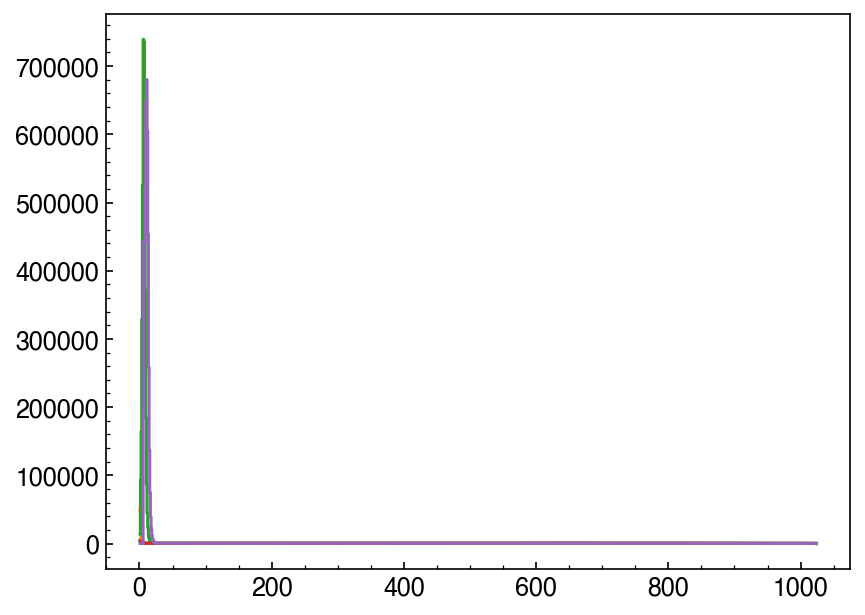

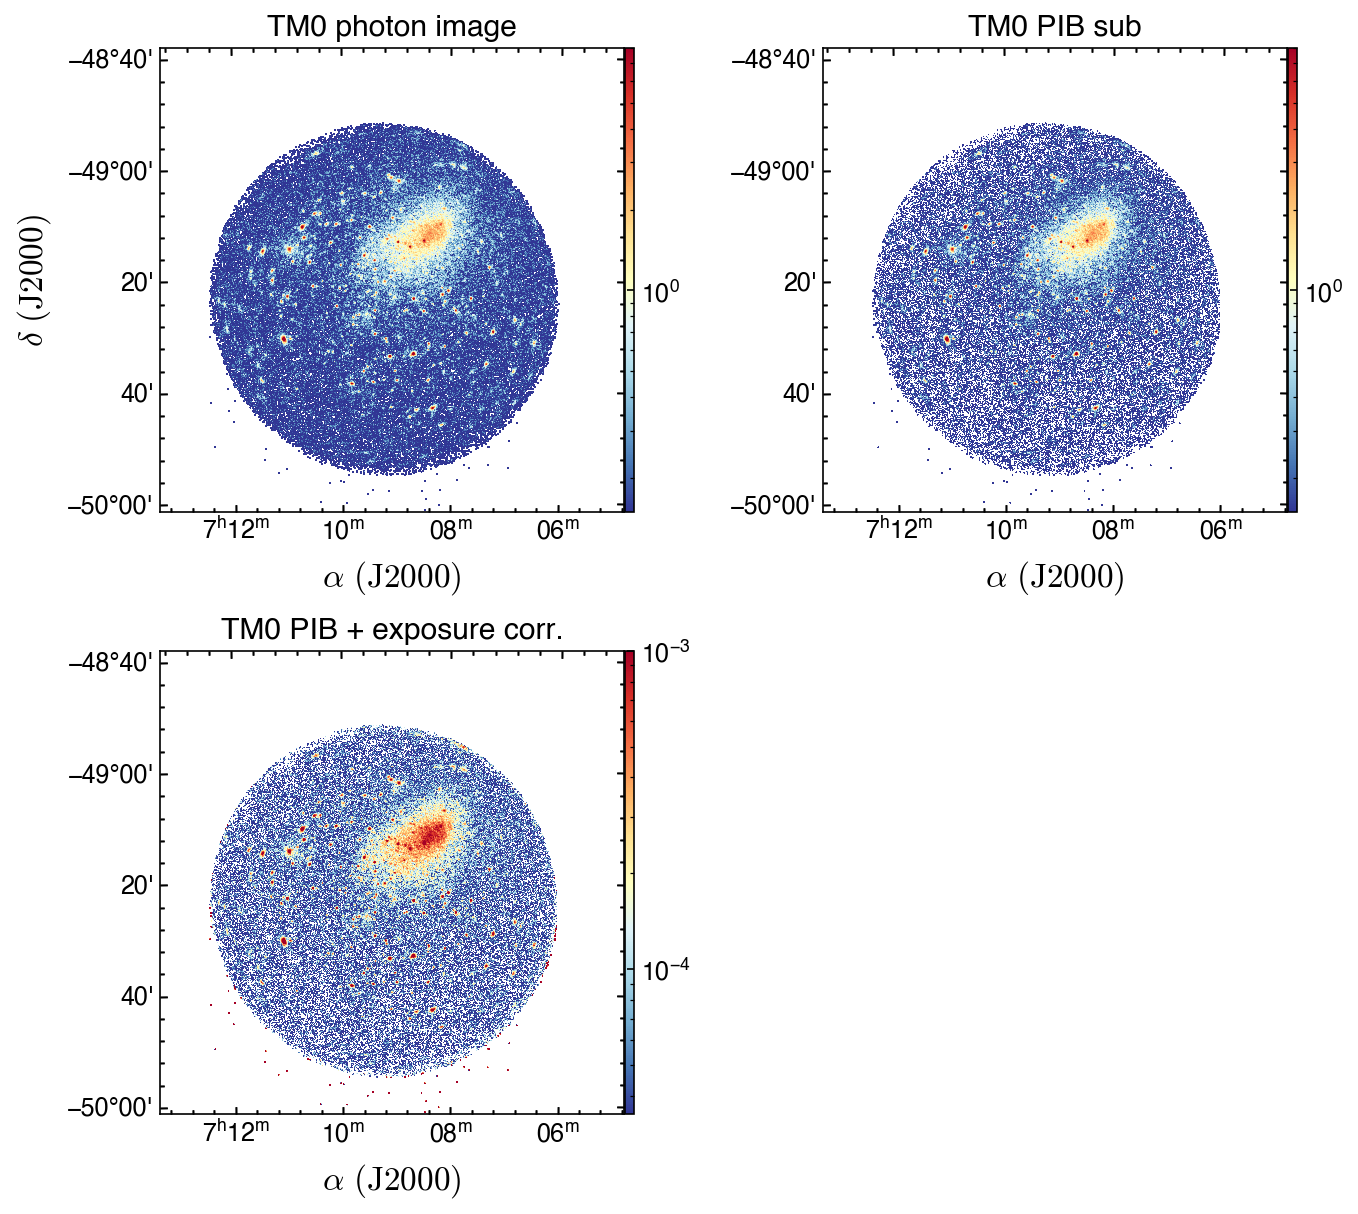

In [28]:

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy.wcs import WCS

# constants
energy_min = 5000  # lower bound in ev
energy_max = 9000  # upper bound in ev
tms = [1, 2, 5, 6, 7]  # telescope modules
data_dir = "data"
full_eband_dir = os.path.join(data_dir, "full_eband")
fwc_bkg_dir = os.path.join(data_dir, "fwc", "bkg_spec")
fwc_src_dir = os.path.join(data_dir, "fwc", "source_spec")
#expmap_dir = os.path.join(data_dir, "expmaps")

filtered = fits.open('data/full_eband/tm0_eventfile.fits')

events = filtered['EVENTS'].data

times = events['TIME']
energies = events['PI']
energy_cut = (energies >= 5000)&(energies <=9000)

x_time = times[energy_cut]

# load observation files
def load_observation_files():
    '''
        load observation fits files for photon image
          and exposure maps
    '''
    obs_files = [f for f in sorted(os.listdir(full_eband_dir)) if f.endswith('.fits')]
    if not obs_files:
        print("error: no fits files found in full_eband directory")
        return None, None, None
    obs = fits.open(os.path.join(full_eband_dir, "tm0_eventfile.fits"))
    tm0_photon_image = fits.open(os.path.join(full_eband_dir, "tm0_soft_band_8_23eV.fits"))
    nonvign_expmap = fits.open(os.path.join(full_eband_dir, "tm0_nonvignetted_expmap.fits"))
    vign_expmap = fits.open(os.path.join(full_eband_dir, "tm0_vignetted_expmap.fits"))
    
    return tm0_photon_image, nonvign_expmap, vign_expmap, obs

# load fwc spectra and rmf
def load_fwc_files(tm):
    '''
        load fwc source spectrum, background spectrum,
          and rmf for a given TM.
    '''
    rmf_file = os.path.join(fwc_bkg_dir, f"pc00TM{tm}_FWC1.0_{tm}00_RMF_c946.fits")
    src_file = os.path.join(fwc_src_dir, f"TM{tm}_FWC_c010_{tm}20_SourceSpec_pat15.fits")
    bkg_file = os.path.join(fwc_bkg_dir, f"pc00TM{tm}_FWC1.0_{tm}00_BackgrSpec_c946.fits")
    
    for f in [rmf_file, src_file, bkg_file]:
        if not os.path.exists(f):
            print(f"error: file not found: {f}")
            return None, None, None
    
    rmf_data = fits.open(rmf_file)['EBOUNDS'].data
    src_spec = fits.open(src_file)['SPECTRUM'].data
    bkg_spec = fits.open(bkg_file)['SPECTRUM'].data
    
    return rmf_data, src_spec, bkg_spec

# process tm data
def process_tm_data(tm, obs, energy_min, energy_max):
    '''
        process data for a single tm, computing hard
          and soft band counts.
    '''
    events = obs['EVENTS'].data
    times = events['TIME']
    energies = events['PI']
    #gti = photon_image['FLAREGTI1'].data

    # define energy masks
    hband_mask = ((energies >= energy_min) & (energies <= energy_max))
    sband_mask = (energies >= 800) & (energies <= 2300) # (energies >= (800 if tm in [5, 7] else 200)) & (energies <= 2300)
    
    # count hard band events
    filtered_times = times[hband_mask]
    hband_counts = len(filtered_times)
    #total_exposure = np.sum(gti['STOP'] - gti['START'])
    
    # load fwc data
    rmf_data, src_spec, bkg_spec = load_fwc_files(tm)
    if rmf_data is None:
        return None, None, None, None, hband_counts
    
    # compute fwc energy bins
    fwc_energies = (rmf_data['E_MIN'] + rmf_data['E_MAX']) / 2
    fwc_hband_mask = (fwc_energies >= 5.0) & (fwc_energies <= 9.0)
    fwc_sband_mask = (fwc_energies >= 0.8) & (fwc_energies <= 2.3)   # (fwc_energies >= (0.8 if tm in [5, 7] else 0.2)) & (fwc_energies <= 2.3)

    pl.plot(src_spec['CHANNEL'], src_spec['COUNTS'], drawstyle='steps-mid', label=f'TM{tm} source')
    
    return src_spec['COUNTS'], bkg_spec['COUNTS'], fwc_hband_mask, fwc_sband_mask, hband_counts

# create background map
def create_background_map(photon_image, nonvign_expmap, hband_counts, src_counts, hband_mask, sband_mask):
    '''
        create a background map using exposure map and fwc spectra.
    '''
    weighted_expmap = nonvign_expmap[0].data / 7
    h_pib = src_counts[hband_mask]
    s_pib = src_counts[sband_mask]
    
    # compute ratio of soft to hard band counts
    r = np.sum(s_pib) / np.sum(h_pib) if np.sum(h_pib) > 0 else 0
    
    # generate background map
    pib_map = (weighted_expmap / np.sum(weighted_expmap)) * hband_counts * r
    fits.writeto('data/full_eband/tm0_pib_map.fits', pib_map, header=photon_image[0].header, overwrite=True)
    print("created background map")
    return pib_map

# plot results
def plot_results(photon_image, pib_map, vign_expmap):
    '''
        plot original, background-subtracted
    '''
    wcs = WCS(photon_image[0].header)
    data = photon_image[0].data
    norm = LogNorm(vmin=0.15, vmax=8)
    
    plt.figure(figsize=(12, 9))
    
    # ---original photon image
    plt.subplot(221, projection=wcs)
    plt.title('TM0 photon image')
    plt.imshow(data, origin='lower',cmap='RdYlBu_r', norm=norm)
    plt.colorbar(aspect=50, pad=0.002, fraction=0.0196)
    pl.ylabel(r'$\rm \delta\ (J2000)$', fontsize=16)
    pl.xlabel(r'$\rm \alpha\ (J2000)$', fontsize=16)

    # ----background-subtracted image
    bg_subtracted = data - pib_map
    bg_subtracted[bg_subtracted == 0] = np.nan
    plt.subplot(222, projection=wcs)
    plt.title('TM0 PIB sub')
    plt.imshow(bg_subtracted, origin='lower', cmap='RdYlBu_r', norm=norm)
    plt.colorbar(aspect=50, pad=0.002, fraction=0.0196)
    pl.ylabel(r'$\rm \alpha\ (J2000)$', fontsize=16, color='w')
    pl.xlabel(r'$\rm \alpha\ (J2000)$', fontsize=16)
    
    # exposure-corrected image
    exposure_corrected = (data - pib_map) / (nonvign_expmap[0].data / 7)
    fits.writeto('data/full_eband/tm0_pibexp_corrected.fits', exposure_corrected, header=photon_image[0].header, overwrite=True)
    print("saved the exposure corrected map..")
    exposure_corrected[exposure_corrected == 0] = np.nan
    plt.subplot(223, projection=wcs)
    plt.title('TM0 PIB + exposure corr.')
    plt.imshow(exposure_corrected, origin='lower', norm=LogNorm(vmin=0.000035, vmax=0.001), cmap='RdYlBu_r')
    plt.colorbar(aspect=50, pad=0.002, fraction=0.0196)
    pl.xlabel(r'$\rm \alpha\ (J2000)$', fontsize=16)
    pl.ylabel(r'$\rm \alpha\ (J2000)$', fontsize=16, color='w')
    pl.subplots_adjust(right=.8, top=.9, hspace=.3, wspace=.2)
    plt.savefig('tm0_pib_corrected.pdf', format='pdf', dpi=150, bbox_inches='tight')
    plt.show()

# main execution
# load observation data
tm0_photon_image, nonvign_expmap, vign_expmap, obs = load_observation_files()
if tm0_photon_image is None:
    print("failed to load observation files")
else:
    # initialize accumulators
    fwc_src_counts = 0
    fwc_bkg_counts = 0
    bg_sub_counts = 0
    
    # process each tm
    for tm in tms:
        src_counts, bkg_counts, hband_mask, sband_mask, hband_counts = process_tm_data(
            tm, obs, energy_min, energy_max
        )
        if src_counts is None:
            print(f"skipping tm{tm} due to file errors")
            continue
        fwc_src_counts += src_counts
        fwc_bkg_counts += bkg_counts
        bg_sub_counts += fwc_src_counts[hband_mask]
    
    # create background map
    pib_map = create_background_map(
        tm0_photon_image, nonvign_expmap, hband_counts, fwc_src_counts, hband_mask, sband_mask
    )
    
    # plot results
    plot_results(tm0_photon_image, pib_map, vign_expmap)


In [ ]:
sr = process_tm_data(

 [astropy.io.fits.verify]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1996/03/13' to '1996-03-13''. [astropy.wcs.wcs]


selected 50 bright optical sources

 optical source coordinates:
source 1: RA=107.882985°, Dec=-49.425895°
source 2: RA=107.703762°, Dec=-48.933365°
source 3: RA=107.882386°, Dec=-49.427111°
source 4: RA=107.697586°, Dec=-48.924324°
source 5: RA=107.880482°, Dec=-49.425655°
source 6: RA=107.881802°, Dec=-49.426643°
source 7: RA=107.883443°, Dec=-49.423790°
source 8: RA=106.980612°, Dec=-48.917936°
source 9: RA=107.674150°, Dec=-48.933869°
source 10: RA=106.983220°, Dec=-48.917754°
source 11: RA=107.884548°, Dec=-49.426506°
source 12: RA=107.031167°, Dec=-49.118242°
source 13: RA=107.693492°, Dec=-48.925988°
source 14: RA=107.123474°, Dec=-49.214137°
source 15: RA=107.673806°, Dec=-48.933322°
source 16: RA=106.419045°, Dec=-48.839725°
source 17: RA=107.246066°, Dec=-48.947800°
source 18: RA=106.668887°, Dec=-49.233938°
source 19: RA=107.730746°, Dec=-49.439730°
source 20: RA=107.731881°, Dec=-49.440621°
source 21: RA=107.878142°, Dec=-49.423637°
source 22: RA=106.975416°, Dec=-48.726610

this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
this form of the PCi_ja keyword is deprecated, use PCi_ja. [astropy.wcs.wcs]
Changed DATE-OBS from '1996/03/13' to '1996-03-13''. [astropy.wcs.wcs]


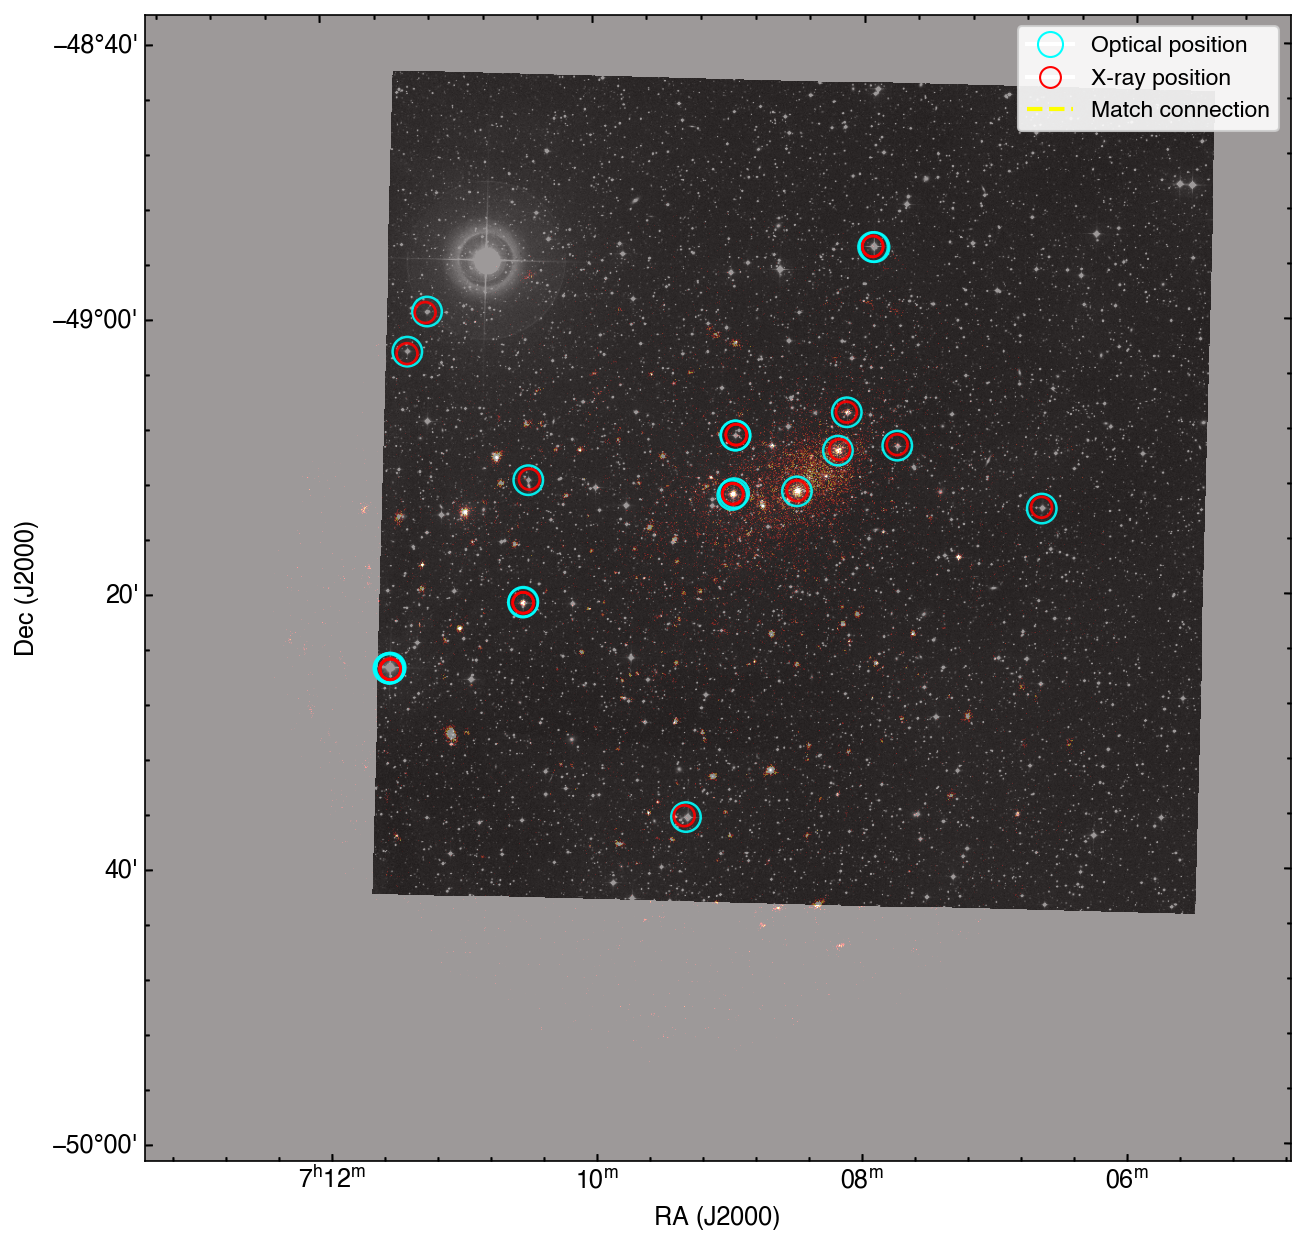

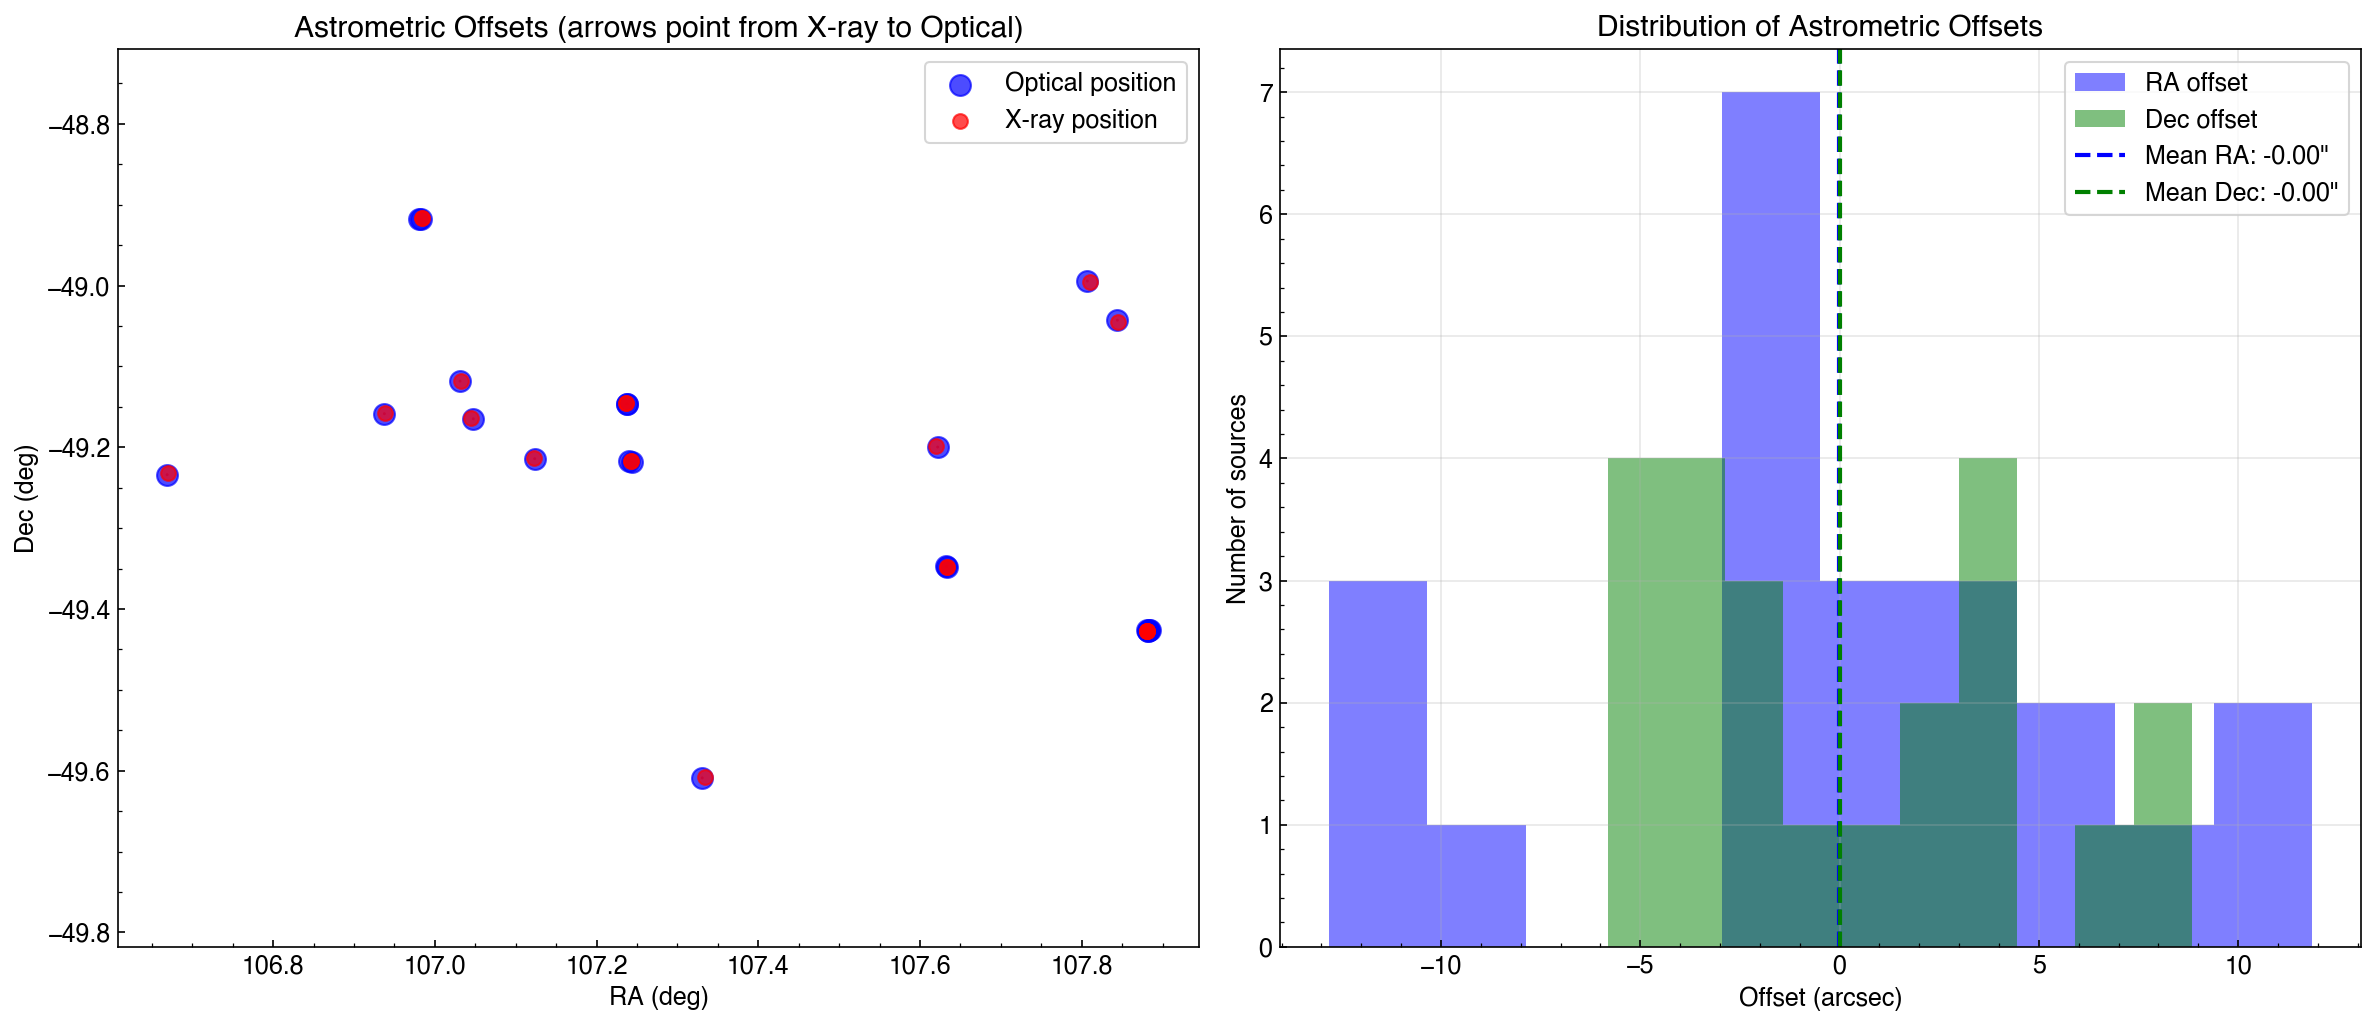

In [249]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from reproject import reproject_interp
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from astropy.table import Table

xray = fits.open('data/full_eband/tm0_soft_band_8_23eV_wcs_corrected.fits')
optical = fits.open('data/full_eband/dss2red.fits')

xray_wcs = WCS(xray[0].header)
optical_wcs = WCS(optical[0].header)
xray_data = xray[0].data
optical_data = optical[0].data

# detect optical sources to serve as a reference 

mean, median, std = sigma_clipped_stats(optical_data, sigma=3.0)
daofind_optical = DAOStarFinder(fwhm=5.0, threshold=5.*std)
optical_sources = daofind_optical(optical_data - median)

# sort by flux and take brightest 15-20 sources (easier to identify in X-ray)
optical_sources.sort('flux')
optical_sources.reverse()
n_sources = min(50, len(optical_sources))
bright_optical = optical_sources[:n_sources]

print(f"selected {n_sources} bright optical sources")

# convert optical source positions to RA/Dec

optical_coords = optical_wcs.pixel_to_world(
    bright_optical['xcentroid'], 
    bright_optical['ycentroid']
)

print("\n optical source coordinates:")
for i, coord in enumerate(optical_coords):
    print(f"source {i+1}: RA={coord.ra.deg:.6f}°, Dec={coord.dec.deg:.6f}°")

# deteect X-ray sources
mean, median, std = sigma_clipped_stats(xray_data, sigma=3.0)
daofind_xray = DAOStarFinder(fwhm=3.0, threshold=3.*std)
xray_sources = daofind_xray(xray_data - median)

if xray_sources is None or len(xray_sources) == 0:
    print("No X-ray sources detected - try lowering threshold")
else:
    print(f"\nfound {len(xray_sources)} X-ray sources")
    
    # convert pixels to ra/dec

    xray_coords = xray_wcs.pixel_to_world(
        xray_sources['xcentroid'], 
        xray_sources['ycentroid']
    )
    
    # cross-match X-ray/optical sources
    idx, d2d, d3d = optical_coords.match_to_catalog_sky(xray_coords)
    
    # analyze offsets
    match_radius = 10 * u.arcsec
    matches = d2d < match_radius
    
    print(f"\n{np.sum(matches)} sources matched within {match_radius}")
    
    if np.sum(matches) > 3:
        # calculate ra and dec offsets
        matched_optical = optical_coords[matches]
        matched_xray = xray_coords[idx[matches]]
        
        # offset = optical - xray pos
        ra_offset = (matched_optical.ra - matched_xray.ra).to(u.arcsec)
        dec_offset = (matched_optical.dec - matched_xray.dec).to(u.arcsec)
        
        # stats - simple mean/median/stddev
        mean_ra_offset = np.mean(ra_offset.value)
        mean_dec_offset = np.mean(dec_offset.value)
        median_ra_offset = np.median(ra_offset.value)
        median_dec_offset = np.median(dec_offset.value)
        std_ra_offset = np.std(ra_offset.value)
        std_dec_offset = np.std(dec_offset.value)
        
        print("\n" + "="*60)
        print("astrometric offset results:")
        print("="*60)
        print(f"mean RA offset:    {mean_ra_offset:+.2f} ± {std_ra_offset:.2f} arcsec")
        print(f"mean Dec offset:   {mean_dec_offset:+.2f} ± {std_dec_offset:.2f} arcsec")
        print(f"median RA offset:  {median_ra_offset:+.2f} arcsec")
        print(f"median Dec offset: {median_dec_offset:+.2f} arcsec")
        
        total_offset = np.sqrt(mean_ra_offset**2 + mean_dec_offset**2)

        print(f"\ntotal systematic offset: {total_offset:.2f} arcsec")
        print("="*60)
        
        # write to a table
        match_table = Table()
        match_table['source_id'] = np.arange(1, np.sum(matches)+1)
        match_table['optical_ra'] = matched_optical.ra.deg
        match_table['optical_dec'] = matched_optical.dec.deg
        match_table['xray_ra'] = matched_xray.ra.deg
        match_table['xray_dec'] = matched_xray.dec.deg
        match_table['ra_offset_arcsec'] = ra_offset.value
        match_table['dec_offset_arcsec'] = dec_offset.value
        match_table['separation_arcsec'] = d2d[matches].to(u.arcsec).value
        
        match_table.write('astrometry_matches.csv', overwrite=True)
        print("\n detailed matches saved to: astrometry_matches.csv")
        
        # overlay plot with marked
        print("\nCreating overlay image...")
        
        # reproject optical to X-ray WCS
        optical_reproj, footprint = reproject_interp(
            optical, 
            xray_wcs, 
            shape_out=xray_data.shape
        )
        
        fig = plt.figure(figsize=(12, 9))
        ax = plt.subplot(projection=xray_wcs)
        
        # show optical as grayscale background
        optical_vmin = np.percentile(optical_reproj[~np.isnan(optical_reproj)], 1)
        optical_vmax = np.percentile(optical_reproj[~np.isnan(optical_reproj)], 99)
        ax.imshow(optical_reproj, cmap='gray', origin='lower', 
                  vmin=optical_vmin, vmax=optical_vmax, alpha=0.8)
        
        # overlay X-ray as semi-transparent colored image
        xray_vmin = np.percentile(xray_data[xray_data > 0], 10)
        xray_vmax = np.percentile(xray_data[xray_data > 0], 99)
        ax.imshow(xray_data, cmap='hot', origin='lower', alpha=0.4,
                  vmin=xray_vmin, vmax=xray_vmax)
        
        # markers for matched sources
        for i, (opt_coord, xray_coord) in enumerate(zip(matched_optical, matched_xray)):
            # optical source - blue circle
            ax.scatter(opt_coord.ra.deg, opt_coord.dec.deg, 
                      transform=ax.get_transform('world'),
                      s=200, facecolors='none', edgecolors='cyan', 
                      linewidths=1.2, marker='o', alpha=0.9)
            
            # X-ray source - red circle
            ax.scatter(xray_coord.ra.deg, xray_coord.dec.deg, 
                      transform=ax.get_transform('world'),
                      s=100, facecolors='none', edgecolors='red', 
                      linewidths=1.3, marker='o', alpha=0.9)
            
            # # Draw line connecting matched pairs
            # ax.plot([opt_coord.ra.deg, xray_coord.ra.deg],
            #        [opt_coord.dec.deg, xray_coord.dec.deg],
            #        transform=ax.get_transform('world'),
            #        color='yellow', linewidth=1.5, alpha=0.6, linestyle='--')
            
            # # Add source number label
            # ax.text(opt_coord.ra.deg, opt_coord.dec.deg, f'  {i+1}', 
            #        transform=ax.get_transform('world'),
            #        color='white', fontsize=10, fontweight='bold',
            #        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
        
        #ax.coords.grid(color='white', alpha=0.3, linestyle='--')
        ax.coords[0].set_axislabel('RA (J2000)', fontsize=12)
        ax.coords[1].set_axislabel('Dec (J2000)', fontsize=12)
        
        # # Title with offset info
        # ax.set_title(f'Abell 3408: Optical (gray) + X-ray (hot)\n'
        #             f'Matched Sources (n={np.sum(matches)}) | '
        #             f'Offset: RA={mean_ra_offset:+.2f}" Dec={mean_dec_offset:+.2f}"',
        #             fontsize=14, fontweight='bold', pad=20)
        
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='cyan', markersize=12, linewidth=2,
                   label='Optical position'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='red', markersize=10, linewidth=2,
                   label='X-ray position'),
            Line2D([0], [0], color='yellow', linewidth=2, linestyle='--',
                   label='Match connection')
        ]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11,
                 framealpha=0.9)
        
        pl.tight_layout()
        pl.subplots_adjust(top=0.92, right=0.95)
        pl.savefig('overlay_with_matches.pdf', format='pdf', dpi=150, bbox_inches='tight')
        pl.show()
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Left: Quiver plot showing offset vectors
        ax = axes[0]
        ax.quiver(matched_optical.ra.deg, matched_optical.dec.deg,
                  ra_offset.value/3600, dec_offset.value/3600,
                  angles='xy', scale_units='xy', scale=1, 
                  color='red', width=0.003, alpha=0.7)
        ax.scatter(matched_optical.ra.deg, matched_optical.dec.deg, 
                   c='blue', s=100, alpha=0.7, label='Optical position')
        ax.scatter(matched_xray.ra.deg, matched_xray.dec.deg, 
                   c='red', s=50, alpha=0.7, label='X-ray position')
        ax.set_xlabel('RA (deg)')
        ax.set_ylabel('Dec (deg)')
        ax.set_title('Astrometric Offsets (arrows point from X-ray to Optical)')
        ax.legend()
        #ax.grid(True, alpha=0.3)
        ax.axis('equal')
        
        # hist of the offsets
        ax = axes[1]
        ax.hist(ra_offset.value, bins=10, alpha=0.5, label='RA offset', color='blue')
        ax.hist(dec_offset.value, bins=10, alpha=0.5, label='Dec offset', color='green')
        ax.axvline(mean_ra_offset, color='blue', linestyle='--', linewidth=2, 
                   label=f'Mean RA: {mean_ra_offset:.2f}"')
        ax.axvline(mean_dec_offset, color='green', linestyle='--', linewidth=2,
                   label=f'Mean Dec: {mean_dec_offset:.2f}"')
        ax.set_xlabel('Offset (arcsec)')
        ax.set_ylabel('Number of sources')
        ax.set_title('Distribution of Astrometric Offsets')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        pl.tight_layout()
        pl.savefig('astrometry_offset_analysis.pdf', format='pdf', dpi=150, bbox_inches='tight')
        pl.show()
        
    else:
        print("\nNot enough matches found. Try:")
        print("- Increasing match_radius")
        print("- Lowering X-ray detection threshold")
        print("- Checking if images actually overlap")

/var/folders/3d/y9v02zfn3jx0vssyx0tpsj000000gn/T/ipykernel_9037/4272947577.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(data_file, comment='#', delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
Set OBSGEO-B to   -30.713200 from OBSGEO-[XYZ].
Set OBSGEO-H to     1046.994 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]


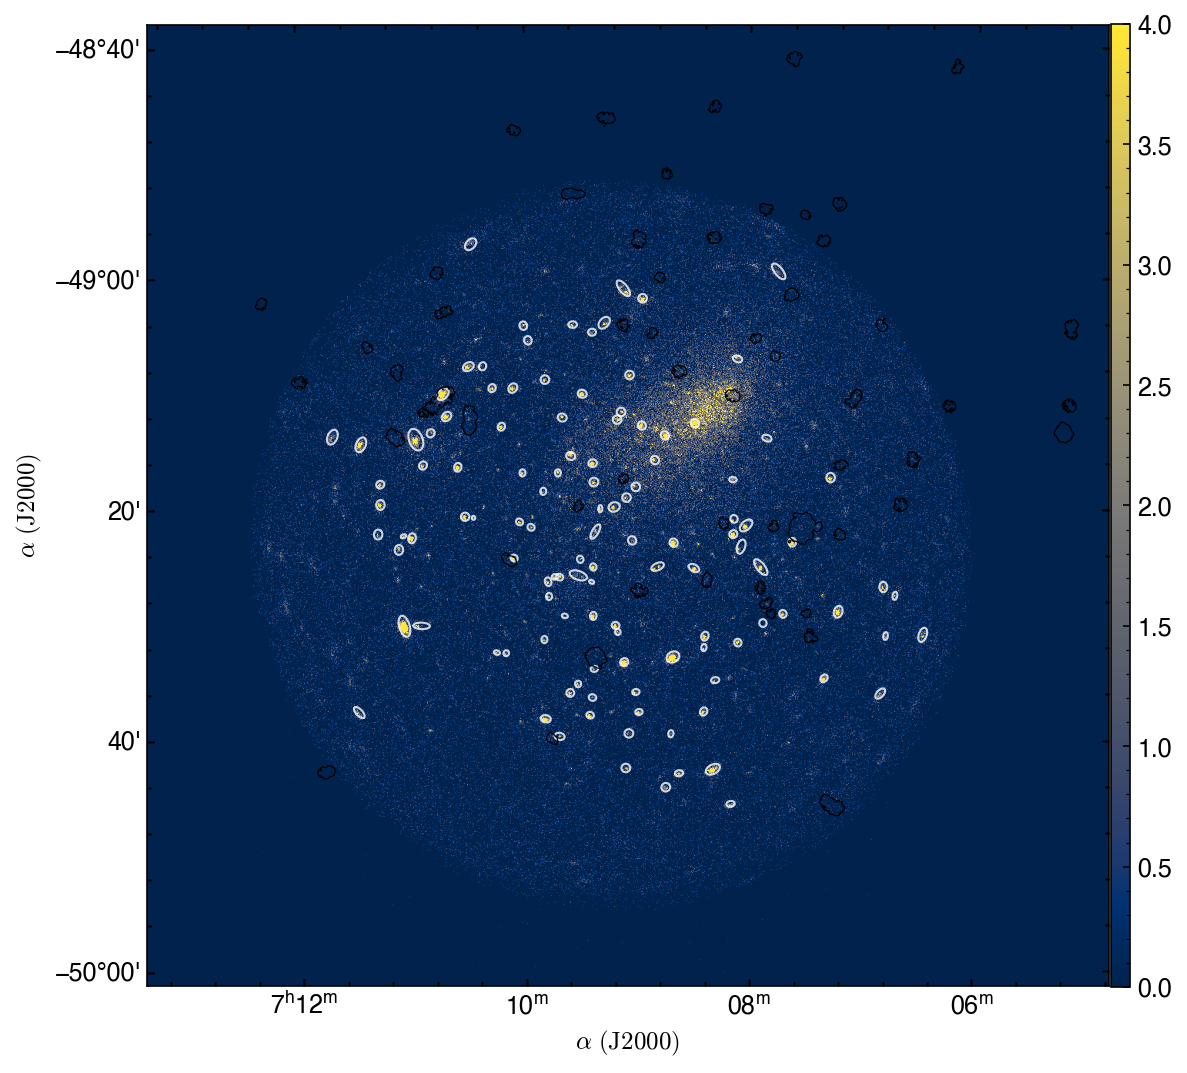

(<Figure size 1200x1200 with 2 Axes>, <WCSAxes: >)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd
import astropy.io.fits as fits

columns = [
    'NUMBER', 'X_IMAGE', 'Y_IMAGE',
    'FLUX_APER_1', 'FLUX_APER_2',
    'FLUXERR_APER_1', 'FLUXERR_APER_2',
    'MAG_APER_1', 'MAG_APER_2',
    'MAGERR_APER_1', 'MAGERR_APER_2',
    'FLUX_AUTO', 'FLUXERR_AUTO',
    'MAG_AUTO', 'MAGERR_AUTO',
    'A_IMAGE', 'B_IMAGE', 'THETA_IMAGE', 'FWHM_IMAGE', 'FLAGS'
]


def plot_apertures(data_file, image_file=None, scale_factor=2.0):
    '''
        - plot elliptical apertures around detected sources
        
        pars:
        -----------
        data_file : str
            path to the source extraction file
        image_file : str, optional
            Path to the original image file, if you want to display it
        scale_factor : float, optional
            scaling factor for the aperture size (default: 2.0)
            typically ellipse size needs to be scaled from the RMS values
    '''

    try:

        data = fits.getdata(data_file, 1)
        df = pd.DataFrame(data)
    except:
        try:
            df = pd.read_csv(data_file, comment='#', delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
        except:
            df = pd.read_csv(data_file, comment='#', delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
    
    fig = plt.figure(figsize=(8, 8))
    
    if image_file:
        try:

            hi_hdu = fits.open('data/full_eband/cluster_dilated_mom0.fits')[0]  # HI image (2600x2600)
            xray_hdu = fits.open(image_file)[0]  # X-ray image (1250x1250)

            # Extract data and WCS
            hi_data = hi_hdu.data
            hi_wcs = WCS(hi_hdu.header, naxis=2)
            xray_data = xray_hdu.data
            xray_wcs = WCS(xray_hdu.header)

            # Step 2: Reproject the HI data to match the X-ray image's WCS and shape
            # reproject_interp returns the reprojected data and a footprint (where data is valid)
            hi_reprojected, footprint = reproject_interp(
                (hi_data, hi_wcs),  # Input data and WCS
                xray_wcs,  # Target WCS (X-ray)
                shape_out=xray_data.shape  # Target shape (1250x1250)
            )
            
            image_data = fits.getdata(image_file)
            vmin, vmax = np.percentile(image_data, [5, 99])
            ax = fig.add_subplot(111, projection=xray_wcs)
            img = ax.imshow(image_data, cmap='cividis', origin='lower', vmin=0, vmax=4)
            cb = pl.colorbar(img, ax=ax, aspect=50, pad=0.002, fraction=0.0196)
            cb.ax.tick_params(labelsize=12)

            levels=[1.5]#, 1.5, 2.5, 3.5, 4.5]
            ax.contour(hi_reprojected, levels=[4], colors='k', linewidths=.6)

        except:
            print("could not load image file. proceeding with blank background.")
    
    for i in range(len(df)):
        x = df['X_IMAGE'][i]
        y = df['Y_IMAGE'][i]
        a = scale_factor * df['A_IMAGE'][i]  # Scale the semi-major axis
        b = scale_factor * df['B_IMAGE'][i]  # Scale the semi-minor axis
        theta = df['THETA_IMAGE'][i]  # Position angle in degrees
        
        ellipse = Ellipse(xy=(x-.5, y-12), width=2*a, height=2*b, angle=theta,
                          edgecolor='white', facecolor='none', alpha=0.8)
        
        ax.add_patch(ellipse)
        
        # ax.text(x-.5, y-25, str(df['NUMBER'][i]), color='red', fontsize=5,
        #         ha='center', va='center')
    
    pl.ylabel(r'$\rm \alpha\ (J2000)$', fontsize=12)
    pl.xlabel(r'$\rm \alpha\ (J2000)$', fontsize=12)
    plt.subplots_adjust(right=1.3, top=.8)
    plt.tight_layout()
    plt.savefig('aperture_sources.pdf', format='pdf', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig, ax

plot_apertures('data/full_eband/sources_corrected.cat',  "data/full_eband/tm0_soft_band_8_23eV.fits", scale_factor=2.5)

/var/folders/3d/y9v02zfn3jx0vssyx0tpsj000000gn/T/ipykernel_9037/2718056315.py:52: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
/var/folders/3d/y9v02zfn3jx0vssyx0tpsj000000gn/T/ipykernel_9037/2718056315.py:142: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')


saved masked image to data/full_eband/tm0_pib_map_masked.fits


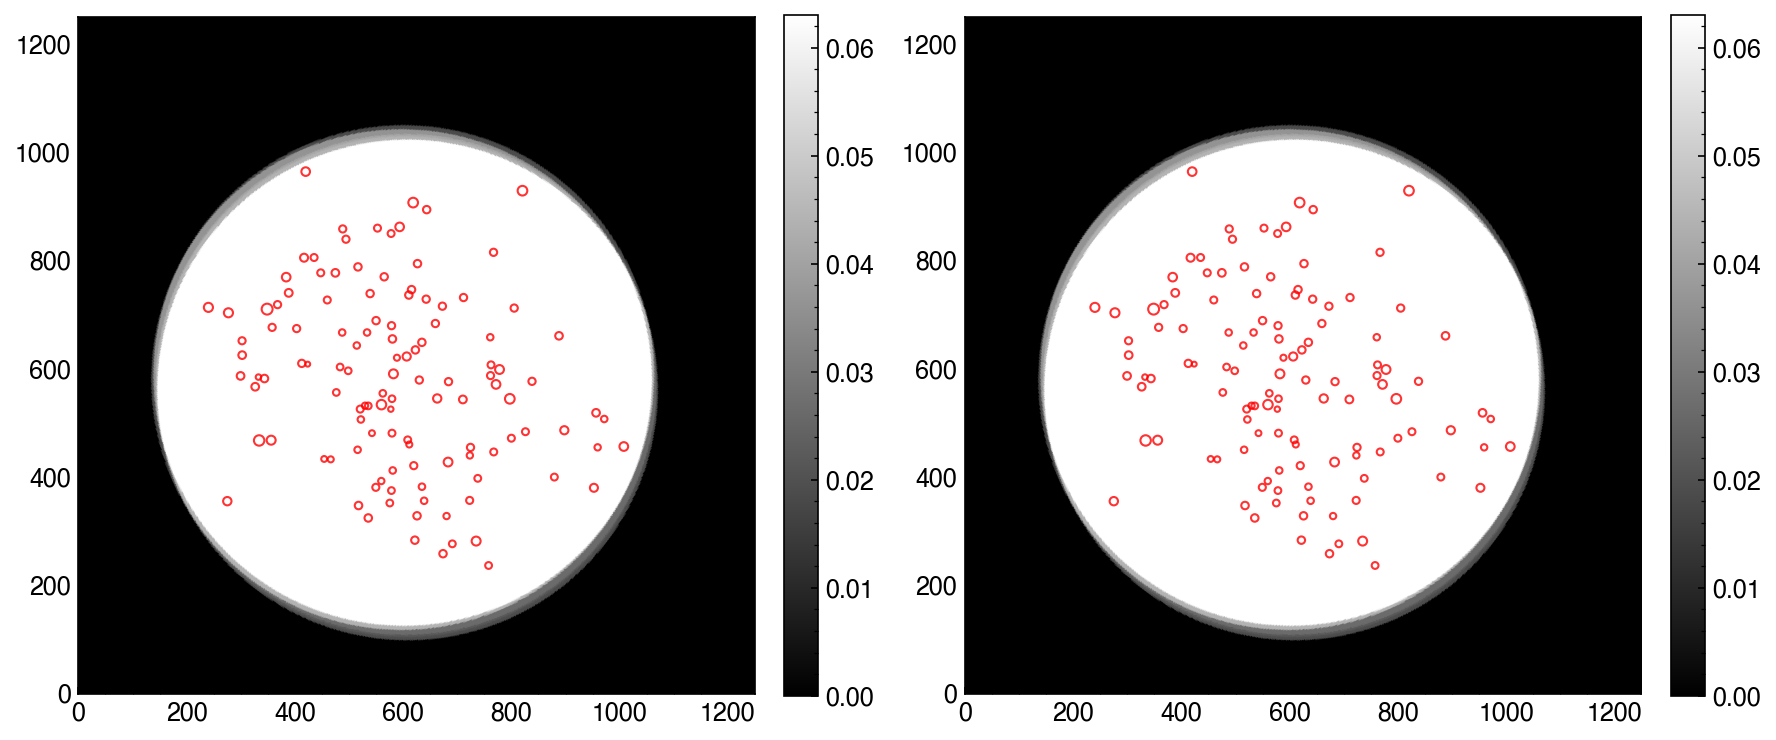

saved mask to data/full_eband/catalog_cheesemask.fits


In [16]:
#using the 

import pylab as pl
import numpy as np
import pandas as pd
from astropy.io import fits
from scipy.ndimage import binary_dilation

columns = [
    'NUMBER', 'X_IMAGE', 'Y_IMAGE',
    'FLUX_APER_1', 'FLUX_APER_2',
    'FLUXERR_APER_1', 'FLUXERR_APER_2',
    'MAG_APER_1', 'MAG_APER_2',
    'MAGERR_APER_1', 'MAGERR_APER_2',
    'FLUX_AUTO', 'FLUXERR_AUTO',
    'MAG_AUTO', 'MAGERR_AUTO',
    'A_IMAGE', 'B_IMAGE', 'THETA_IMAGE', 'FWHM_IMAGE', 'FLAGS'
]


def create_cheesemask(source_catalog, image_shape, scale_factor=2.0, dilation_iterations=1):
    '''
        - creates a cheesemask from a source catalog with circular masked regions.
    
        pars:
        -----------
        source_catalog : str or pandas.DataFrame
            path to the source extraction file or DataFrame with source data.
        image_shape : tuple
            shape of the original image (height, width).
        scale_factor : float, optional
            scaling factor for the circular radius (default: 3.0).
        dilation_iterations : int, optional
            number of iterations for dilating the mask (default: 1).

        output:
        --------
        mask : numpy.ndarray
            boolean mask 
    '''
    # load the data if a string is provided (file path)

    if isinstance(source_catalog, str):
        try:
            # try loading as FITS table  - incase of FITS catalog file

            data = fits.getdata(source_catalog, 1)
            df = pd.DataFrame(data)
        except:
            try:
                # for source catalogs in .csv or whatever format
                df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
            except:
                # for space-delimited file
                df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
    else:
        # else it's a df
        df = source_catalog
    
    # create an empty mask 
    mask = np.ones(image_shape, dtype=bool)
    
    # create a meshgrid for the entire image
    y, x = np.ogrid[:image_shape[0], :image_shape[1]]
    
    # for each source, create a circular mask
    for i in range(len(df)):
        x_center = df['X_IMAGE'][i] - .5, 
        y_center = df['Y_IMAGE'][i] - 12
        a = df['A_IMAGE'][i]  # semi - major axis
        b = df['B_IMAGE'][i]  # || - minor axis
        radius = scale_factor * np.sqrt(a**2 + b**2)  # circular radius
        
        # skip sources outside the image bounds (with margin)

        if (x_center < -radius or x_center > image_shape[1] + radius or 
            y_center < -radius or y_center > image_shape[0] + radius):
            continue
            
    
        # (x - x_center)² + (y - y_center)² <= radius² -- circular eqn for each pixel
        circle = ((x - x_center)**2 + (y - y_center)**2) <= radius**2
        
        # set the circular region to False (masked)
        mask[circle] = False
    
    # optionally dilate the mask to expand the masked regions
    if dilation_iterations > 0:
        mask = binary_dilation(~mask, iterations=dilation_iterations)
        mask = ~mask  # invert back
    
    return mask

def plot_cheesemask(source_catalog, image_file, scale_factor=1.5, dilation_iterations=1, 
                   show_sources=False, output_file=None):
    '''
        plots the cheesemask applied image
        
        pars:
        -----------
        source_catalog : same as above
        image_file : str
            path to the photon image file
        scale_factor, dilation_iterations : 
            pars for create_cheesemask function
        show_sources : bool, optional
            whether to overlay source positions on the plot (default: True)
        output_file : str, optional
            if provided, save the masked image to this file
    '''
    with fits.open(image_file) as hdul:
        image_data = hdul[0].data
        header = hdul[0].header
    
    # create the cheesemask
    mask = create_cheesemask(source_catalog, image_data.shape, 
                           scale_factor, dilation_iterations)
    
    # apply mask to the image
    masked_image = image_data.copy()
    masked_image = image_data.astype(float)  # convert to float
    masked_image[~mask] = np.nan  # now NaN assignment will work
    
    # plot the results
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # plot original image
    vmin, vmax = np.percentile(image_data[np.isfinite(image_data)], [1, 99])
    im1 = axes[0].imshow(image_data, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)    
    # plot masked image

    im2 = axes[1].imshow(masked_image, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    
    # overlay source positions if requested
    if show_sources:
        if isinstance(source_catalog, str):
            try:
                data = fits.getdata(source_catalog, 1)
                df = pd.DataFrame(data)
            except:
                try:
                    df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
                except:
                    df = pd.read_csv(source_catalog, delim_whitespace=True, names=columns, skiprows=20, on_bad_lines='warn')
        else:
            df = source_catalog
            
        for ax in axes:
            ax.scatter(df['X_IMAGE']-0.5, df['Y_IMAGE']-12, s=4*np.sqrt(df['A_IMAGE']**2 + df['B_IMAGE']**2), facecolor='none', 
                      edgecolor='red', alpha=0.8)
    
    pl.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    pl.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    pl.tight_layout()
    
    if output_file:
        pl.savefig(output_file, dpi=300, bbox_inches='tight')
        
        masked_fits = output_file.replace('.png', '.fits')
        masked_fits = masked_fits if '.fits' in masked_fits else output_file + '.fits'
        
        hdu = fits.PrimaryHDU(data=masked_image, header=header)
        hdu.writeto(masked_fits, overwrite=True)
        print(f"saved masked image to {masked_fits}")
    
    pl.show()
    
    return mask, masked_image

def save_cheesemask(mask, output_file, header=None):
    '''
        - save the cheesemask to a FITS file
    '''
    hdu = fits.PrimaryHDU(data=mask.astype(np.uint8), header=header)
    hdu.writeto(output_file, overwrite=True)
    print(f"saved mask to {output_file}")

mask, masked_image = plot_cheesemask('data/full_eband/sources_corrected.cat',  "data/full_eband/tm0_pib_map.fits",
                                      show_sources=True,
                                     scale_factor=1.5, dilation_iterations=3, 
                                      output_file='data/full_eband/tm0_pib_map_masked.png') 

save_cheesemask(mask, 'data/full_eband/catalog_cheesemask.fits', header=fits.open("data/full_eband/tm0_pib_map.fits")[0].header)


# exposure_map_file = 'data/full_eband/tm0_nonvignetted_expmap.fits' # non-vignetted exposure map
# background_map_file = 'data/full_eband/tm0_pib_map.fits'  

Set OBSGEO-B to   -30.713200 from OBSGEO-[XYZ].
Set OBSGEO-H to     1046.994 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


PIB uncertainty estimation:
  Hard band sum: 495241.0 counts
  Soft band sum: 231396.0 counts
  Ratio r = 0.4672 ± 0.0012
  Mean PIB uncertainty: 1.144e-04

PIB uncertainty estimated : 0.00011437070356236247.

STEP 2: Estimating CXB Surface Brightness

cxb estimation:
  region center: (376.6, 325.3) pixels
  radius: 42 pixels
  total cts: 683.0
  pib cts: 349.4
  cxb cts: 333.6
  exposure: 121935429.0 s
  Area: 88704.0 arcsec^2
  cxb SB: 1.110e-07 ± 1.069e-08 counts/s/arcsec^2

STEP 3: Calculating Radial Profiles with CXB Subtraction
Cluster center (pixel): x=727.79, y=746.63
Pixel scale: 4.0000 arcsec/pixel
Log binning: 26 bins from 4.6 to 600.0 pixels


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]



Azimuthal Profile (first 5 bins):
   Inner_Radius_Pixels  Outer_Radius_Pixels  Surface_Brightness  \
0             0.000000             4.615385            0.000007   
1             4.615385             5.607453            0.000008   
2             5.607453             6.812764            0.000008   
3             6.812764             8.277155            0.000007   
4             8.277155            10.056314            0.000007   

   Surface_Brightness_Err  
0            5.614328e-07  
1            8.845724e-07  
2            6.817055e-07  
3            5.528920e-07  
4            4.460352e-07  

STEP 4: Fitting Beta Model with MCMC
Running MCMC with 50 walkers for 5000 steps...


  0%|          | 0/5000 [00:00<?, ?it/s]/Users/xola/anaconda3/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:08<00:00, 619.10it/s]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]



Best-fit parameters:
  S0 = 6.982e-06 ± 5.916e-05
  rc = 52.19 ± 15.53 pixels
  beta = 0.631 ± 0.029

Goodness of fit:
  χ² = 98.83
  χ²_red = 6.177 (dof = 16)
R200: 1.5 Mpc = 1809.6 arcsec = 452.4 pixels


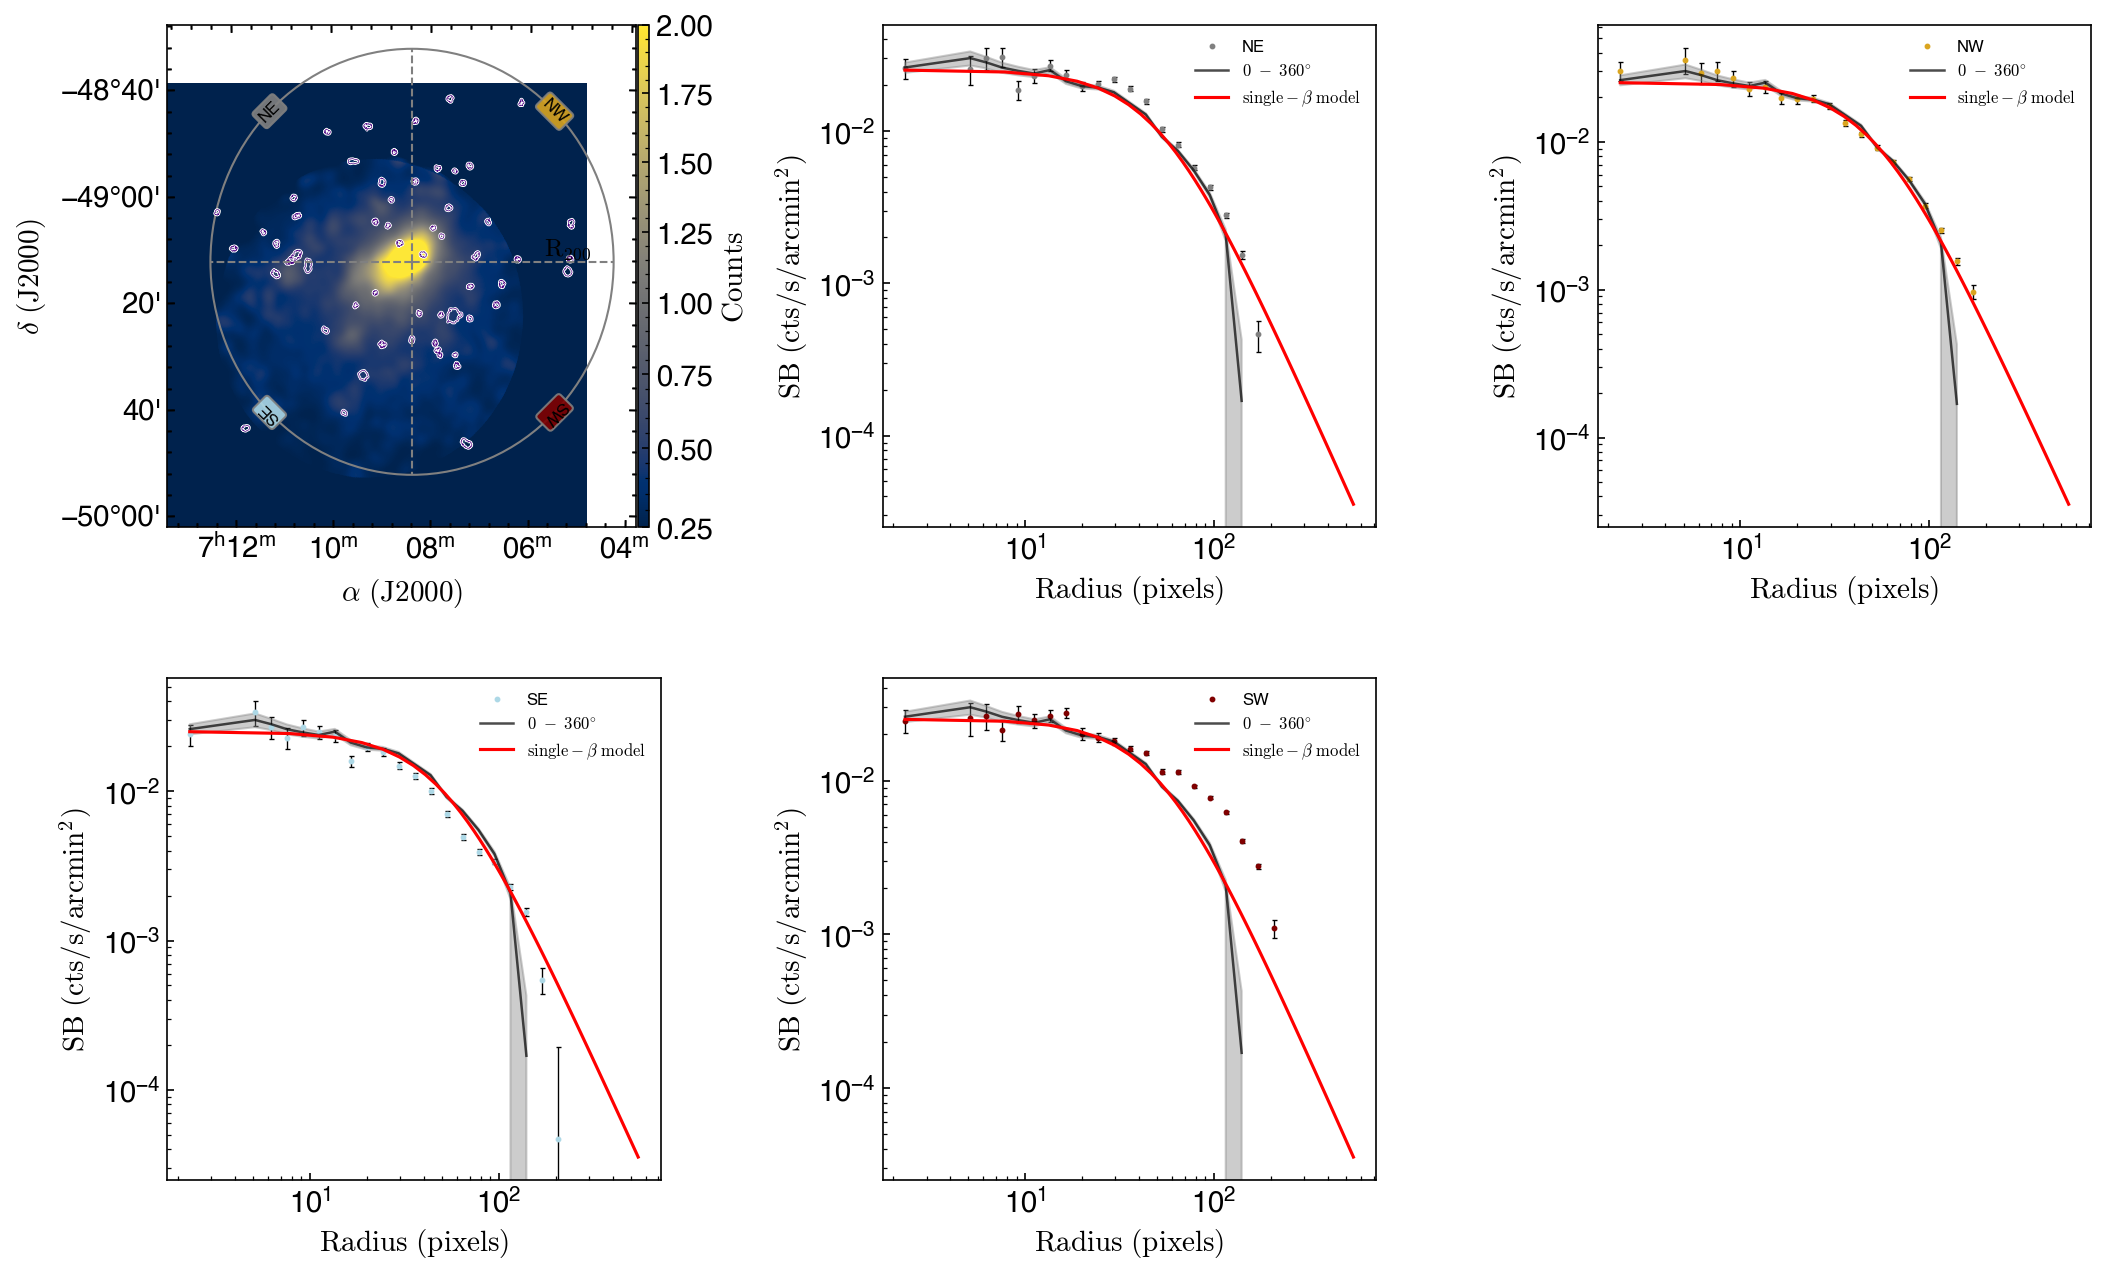

In [ ]:

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord, Angle
from astropy.cosmology import FlatLambdaCDM
from regions import CirclePixelRegion, PixCoord
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.gridspec import GridSpec
import emcee
import corner
from reproject import reproject_interp
import os
import numpy as np
import pylab as pl
import matplotlib as mpl
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt 
import astropy.units as u
import astropy.constants as cc
from astropy.io import fits 
from astropy.cosmology import WMAP9 as cosmo
from astropy.visualization import PowerStretch 
from astropy.visualization.mpl_normalize import ImageNormalize, simple_norm
from astropy.visualization import PercentileInterval 
from scipy import interpolate
from scipy.optimize import curve_fit
mpl.rc('xtick',direction='in') 
from matplotlib.patches import Ellipse
mpl.rc('xtick',direction='in') 
mpl.rc('ytick',direction='in') 
mpl.rcParams['contour.negative_linestyle'] = 'solid' 
plt.rc('font',family='sans-serif',serif='Helvetica',size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 
mpl.rcParams['figure.dpi'] = 150
mpl.rc('xtick',direction='in') 
mpl.rc('xtick',direction='in') 
mpl.rc('ytick',direction='in') 
pl.rcParams["xtick.minor.visible"] =  True
pl.rcParams["ytick.minor.visible"] =  True

mpl.rcParams['font.size'] = 12
mpl.rcParams['xtick.labelsize'] = 12  
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.family'] = 'serif'
#plt.rc('font',family='sans-serif',serif='Helvetica',size=10) 
params = {'text.usetex': False, 'mathtext.fontset': 'cm', 'mathtext.default': 'regular'} 
plt.rcParams.update(params) 

# functions


image_file = 'data/full_eband/tm0_wsc_corrected_cheesemasked.fits'
exposure_map_file = 'data/full_eband/tm0_nonvignetted_expmap_cheesemask.fits'
background_map_file = 'data/full_eband/tm0_pibmap_cheesemask.fits'

xray_hdu = fits.open('data/full_eband/cheesemask_applied.fits')[0]  # X-ray image (1250x1250)
xray_data = xray_hdu.data
xray_wcs = WCS(xray_hdu.header)

hi_hdu = fits.open('data/full_eband/cluster_dilated_mom0.fits')[0]  # HI image (2600x2600)

hi_data = hi_hdu.data
hi_wcs = WCS(hi_hdu.header, naxis=2)

hi_reprojected, footprint = reproject_interp(
    (hi_data, hi_wcs),  # Input data and WCS
    xray_wcs,  # Target WCS (X-ray)
    shape_out=xray_data.shape  # Target shape (1250x1250)
)



def create_quadrant_regions(center_x, center_y, radius, output_file=None):
    '''
        - create regions for the four quadrants (NE, NW, SE, SW) within a circle.
    '''

    circle = CirclePixelRegion(
        center=PixCoord(x=center_x, y=center_y),
        radius=radius,
        meta={'text': 'r200', 'include': True}
    )
    
    quadrants = {
        'NE': (0, 90),
        'NW': (90, 180),
        'SW': (180, 270),
        'SE': (270, 360)
    }
    
    regions = [circle]
    for quadrant, (start_angle, end_angle) in quadrants.items():
        quad_region = CirclePixelRegion(
            center=PixCoord(x=center_x, y=center_y),
            radius=radius,
            meta={'text': quadrant, 'include': True}
        )
        regions.append(quad_region)
    
    if output_file:
        with open(output_file, 'w') as f:
            f.write("# region file format: DS9\n")
            f.write("global color=green dashlist=8 3 width=2 font='helvetica 12 bold' select=1 highlite=1 dash=0\n")
            f.write(f"circle({center_x},{center_y},{radius}) # text={{R200}}\n")
            for quadrant, (start_angle, end_angle) in quadrants.items():
                f.write(f"pie({center_x},{center_y},0,{radius},{start_angle},{end_angle}) # text={{{quadrant}}}\n")
        print(f"\n regions saved to {output_file}\n")
    
    return regions

def create_quadrant_annular_regions(center_x, center_y, radii, output_file_prefix=None):
    '''
        - create annular segment regions for each quadrant.
    '''

    quadrants = {
        'NE': (0, 90),
        'NW': (90, 180),
        'SW': (180, 270),
        'SE': (270, 360)
    }
    
    regions = {quad: [] for quad in quadrants}
    center = PixCoord(x=center_x, y=center_y)
    
    for quad, (start_angle, end_angle) in quadrants.items():
        for i, outer_radius in enumerate(radii):
            if i == 0:
                region = CirclePixelRegion(
                    center=center,
                    radius=outer_radius,
                    meta={'text': f'{quad}_circle_0-{outer_radius}px', 'include': True}
                )
            else:
                region = CirclePixelRegion(
                    center=center,
                    radius=outer_radius,
                    meta={'text': f'{quad}_annulus_{radii[i-1]}-{outer_radius}px', 'include': True}
                )
            regions[quad].append(region)
        
        if output_file_prefix:
            output_file = f"{output_file_prefix}_{quad}.reg"
            with open(output_file, 'w') as f:
                f.write("# region file format: DS9\n")
                f.write("global color=green dashlist=8 3 width=2 font='helvetica 12 bold' select=1 highlite=1 dash=0\n")
                for i, outer_radius in enumerate(radii):
                    inner_radius = 0 if i == 0 else radii[i-1]
                    f.write(f"pie({center_x},{center_y},{inner_radius},{outer_radius},{start_angle},{end_angle}) "
                            f"# text={{{quad}_annulus_{inner_radius}-{outer_radius}px}}\n")
            print(f"\n regions saved to {output_file}\n")
    
    return regions


def estimate_cxb_surface_brightness(image_file, exposure_map_file, background_map_file,
                                    cxb_region_file=None, ra_cxb=None, dec_cxb=None, 
                                    radius_cxb=50, cheesemask=None):
    '''
        estimate CXB surf brightness from a source-free region.
        
        params:
        -----------
        image_file : str
            path to photon image FITS file
        exposure_map_file : str
            path to exposure map FITS file
        background_map_file : str
            path to PIB map FITS file
        cxb_region_file : str, optional
            path to DS9 region file defining CXB extraction region
        ra_cxb, dec_cxb : float, optional
            ra/dec coordinates for CXB region center (if not using region file)
        radius_cxb : float
            radius in pixels for CXB extraction region
        cheesemask : ndarray, optional
            boolean mask for point sources
        
        returns:
        --------
        cxb_sb : float
            cxb surface brightness in counts/s/arcsec^2
        cxb_sb_err : float
            uncertainty in CXB surface brightness
    '''


    with fits.open(image_file) as hdul:
        image_data = hdul[0].data
        header = hdul[0].header
        wcs_obj = WCS(header)
    
    with fits.open(exposure_map_file) as hdul:
        exposure_data = hdul[0].data
    
    with fits.open(background_map_file) as hdul:
        pib_data = hdul[0].data
    
    # get pixel scale
    if 'CDELT1' in header and 'CDELT2' in header:
        pixel_scale = abs(header['CDELT1'] * header['CDELT2']) * 3600**2
    else:
        pixel_scale = 4.0 # know that it is 4 arcsec/pixel
     
    # define cxb extraction region
    if ra_cxb is not None and dec_cxb is not None:
        center_coord = SkyCoord(ra_cxb * u.deg, dec_cxb * u.deg, frame='icrs')
        center_x, center_y = wcs_obj.world_to_pixel(center_coord)
    else:
        # use corner of image by default
        '''
            - need to double check this - corners will not work quite
        '''
        center_x = image_data.shape[1] - 100
        center_y = image_data.shape[0] - 100
    
    # circular mask for cxb region
    y, x = np.indices(image_data.shape)
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    cxb_mask = r <= radius_cxb
    
    # apply cheesemask 
    if cheesemask is not None:
        valid_mask = cxb_mask & cheesemask
    else:
        valid_mask = cxb_mask
    
    # extract data from cxb region
    counts = np.nansum(image_data[valid_mask])
    exposure_sum = np.nansum(exposure_data[valid_mask])
    pib_sum = np.nansum(pib_data[valid_mask])
    n_pixels = np.sum(valid_mask)
    area_arcsec = n_pixels * pixel_scale
    
    # cxb, surface brightness
    # cxb= (cts - PIB) / exposure / area
    cxb_counts = counts - pib_sum
    
    if exposure_sum > 0 and area_arcsec > 0:
        cxb_sb = cxb_counts / exposure_sum / area_arcsec
        # assoc. uncert : sqrt(counts + PIB) / exposure / area
        cxb_sb_err = np.sqrt(counts + pib_sum) / exposure_sum / area_arcsec
    else:
        cxb_sb = 0
        cxb_sb_err = 0
    
    print(f"\ncxb estimation:")
    print(f"  region center: ({center_x:.1f}, {center_y:.1f}) pixels")
    print(f"  radius: {radius_cxb} pixels")
    print(f"  total cts: {counts:.1f}")
    print(f"  pib cts: {pib_sum:.1f}")
    print(f"  cxb cts: {cxb_counts:.1f}")
    print(f"  exposure: {exposure_sum:.1f} s")
    print(f"  Area: {area_arcsec:.1f} arcsec^2")
    print(f"  cxb SB: {3600*cxb_sb:.3e} ± {3600*cxb_sb_err:.3e} counts/s/arcsec^2")
    
    return cxb_sb, cxb_sb_err


# function for PIB uncertainty estimation

def estimate_pib_uncertainty_from_components(pib_map_file, exposure_map_file,
                                             hband_counts_map, src_counts, 
                                             hband_mask, sband_mask):
    """
    Estimate PIB uncertainty by propagating uncertainties from FWC components.
    
    PIB = (expmap / sum(expmap)) * N_hard * r
    where r = sum(soft_fwc) / sum(hard_fwc)
    
    Uncertainty propagation:
    sigma_PIB^2 = (expmap/sum_expmap)^2 * [r^2 * N_hard + N_hard^2 * sigma_r^2]
    
    where sigma_r = r * sqrt(1/sum_soft + 1/sum_hard)
    """
    with fits.open(pib_map_file) as hdul:
        pib_data = hdul[0].data
    
    with fits.open(exposure_map_file) as hdul:
        expmap = hdul[0].data
    
    # Calculate ratio from FWC spectra
    h_pib = src_counts[hband_mask]
    s_pib = src_counts[sband_mask]
    sum_h = np.sum(h_pib)
    sum_s = np.sum(s_pib)
    
    if sum_h <= 0 or sum_s <= 0:
        print("Warning: Invalid FWC counts, using Poisson uncertainty")
        return np.sqrt(np.abs(pib_data))
    
    r = sum_s / sum_h
    
    # Uncertainty in ratio (from Poisson statistics of summed counts)
    r_err = r * np.sqrt(1.0/sum_s + 1.0/sum_h)
    
    # Normalized exposure map
    norm_expmap = expmap / np.nansum(expmap)
    
    # Uncertainty in hard band counts (Poisson)
    sigma_hband = np.sqrt(hband_counts_map)
    
    # Propagate uncertainties
    # sigma_PIB^2 = norm^2 * [r^2 * sigma_N^2 + N^2 * sigma_r^2]
    pib_uncertainty = norm_expmap * np.sqrt(
        r**2 * hband_counts_map +  # from Poisson uncertainty in hard counts
        hband_counts_map**2 * r_err**2  # from uncertainty in soft/hard ratio
    )
    
    print(f"PIB uncertainty estimation:")
    print(f"  Hard band sum: {sum_h:.1f} counts")
    print(f"  Soft band sum: {sum_s:.1f} counts")
    print(f"  Ratio r = {r:.4f} ± {r_err:.4f}")
    print(f"  Mean PIB uncertainty: {np.nanmean(pib_uncertainty):.3e}")
    
    return pib_uncertainty

# calculate quadrant surface brightness

def calculate_quadrant_surface_brightness(image_file, exposure_map_file=None, 
                                         background_map_file=None, pib_uncertainty=None,
                                         center_x=None, center_y=None, radius=None,
                                         region_file=None, cheesemask=None):
    '''
        - calculate surface brightness in four quadrants with proper error propagation.
    '''
    
    with fits.open(image_file) as hdul:
        image_data = hdul[0].data
        header = hdul[0].data
    
    if exposure_map_file:
        with fits.open(exposure_map_file) as hdul:
            exposure_data = hdul[0].data
    else:
        exposure_data = np.ones_like(image_data, dtype=float)
    
    if background_map_file:
        with fits.open(background_map_file) as hdul:
            background_data = hdul[0].data
    else:
        background_data = np.zeros_like(image_data, dtype=float)
    
    if pib_uncertainty is None:
        pib_uncertainty = np.sqrt(np.abs(background_data))
    
    if cheesemask is not None:
        masked_image = np.copy(image_data).astype(float)
        masked_exposure = np.copy(exposure_data).astype(float)
        masked_background = np.copy(background_data).astype(float)
        masked_pib_unc = np.copy(pib_uncertainty).astype(float)
        masked_image[~cheesemask] = np.nan
        masked_exposure[~cheesemask] = np.nan
        masked_background[~cheesemask] = np.nan
        masked_pib_unc[~cheesemask] = np.nan
    else:
        masked_image = image_data
        masked_exposure = exposure_data
        masked_background = background_data
        masked_pib_unc = pib_uncertainty
    
    if center_x is None or center_y is None:
        center_y, center_x = np.unravel_index(np.nanargmax(masked_image), masked_image.shape)
        print(f"Estimated center: x={center_x}, y={center_y}")
    
    if radius is None:
        radius = min(masked_image.shape) // 4
        print(f"Using radius: {radius} pixels\n")
    
    if 'CDELT1' in header and 'CDELT2' in header:
        pixel_scale = abs(header['CDELT1'] * header['CDELT2']) * 3600**2
    else:
        pixel_scale = 1.0
        print("Warning: could not determine pixel scale. Using 1.0")
    
    _regions = create_quadrant_regions(center_x, center_y, radius, output_file=region_file)
    
    quadrants = {
        'NE': (0, 90),
        'NW': (90, 180),
        'SW': (180, 270),
        'SE': (270, 360)
    }
    
    results_data = []
    
    for name, (theta1, theta2) in quadrants.items():
        y, x = np.indices(masked_image.shape)
        r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
        theta1_rad = np.deg2rad(theta1)
        theta2_rad = np.deg2rad(theta2)
        theta = np.arctan2(y - center_y, x - center_x)
        theta = (theta + 2*np.pi) % (2*np.pi)
        
        if theta1 < theta2:
            quad_mask = (r <= radius) & (theta >= theta1_rad) & (theta <= theta2_rad)
        else:
            quad_mask = (r <= radius) & ((theta >= theta1_rad) | (theta <= theta2_rad))
        
        valid_mask = np.logical_and(quad_mask, cheesemask) if cheesemask is not None else quad_mask
        
        n_pixels = np.sum(valid_mask)
        counts = np.nansum(masked_image[valid_mask])
        exp_sum = np.nansum(masked_exposure[valid_mask])
        bkg_sum = np.nansum(masked_background[valid_mask])
        area_pixels = n_pixels
        area_arcsec = area_pixels * pixel_scale
        
        # Error propagation:
        # SB = (C - B) / E / A
        # sigma_SB^2 = (1/EA)^2 * (sigma_C^2 + sigma_B^2)
        # where sigma_C = sqrt(C), sigma_B = sqrt(sum of PIB uncertainties squared)
        
        sigma_counts = np.sqrt(counts) if counts > 0 else 0
        sigma_bkg = np.sqrt(np.nansum(masked_pib_unc[valid_mask]**2))
        
        net_counts = counts - bkg_sum
        
        if exp_sum > 0 and area_arcsec > 0:
            sb = net_counts / exp_sum / area_arcsec
            # Proper error propagation
            sb_err = np.sqrt(sigma_counts**2 + sigma_bkg**2) / exp_sum / area_arcsec
        else:
            sb = 0
            sb_err = 0
        
        results_data.append({
            'Region': name,
            'Photon_Counts': counts,
            'Photon_Counts_Err': sigma_counts,
            'Exposure_Sum': exp_sum,
            'Background_Counts': bkg_sum,
            'Background_Err': sigma_bkg,
            'Area_Pixels': area_pixels,
            'Area_Arcsec2': area_arcsec,
            'Surface_Brightness': sb,
            'Surface_Brightness_Err': sb_err
        })
    
    results = pd.DataFrame(results_data)
    return results, center_x, center_y

# ============================================================================
# RADIAL PROFILE CALCULATIONS (QUADRANTS + AZIMUTHAL)
# ============================================================================
def calculate_radial_profiles_with_cxb(image_file, exposure_map_file, background_map_file,
                                       pib_uncertainty, cxb_sb, cxb_sb_err,
                                       ra_center=None, dec_center=None, 
                                       max_radius=None, n_bins=10, 
                                       region_file_prefix=None, 
                                       cheesemask=None, include_azimuthal=True):
    """
    Calculate radial surface brightness profiles with CXB subtraction.
    
    Surface Brightness = (Counts - PIB - CXB*Exposure*Area) / Exposure / Area
                       = (Counts - PIB) / Exposure / Area - CXB
    """
    with fits.open(image_file) as hdul:
        image_data = hdul[0].data
        header = hdul[0].header
        wcs = WCS(header)
    
    if exposure_map_file:
        with fits.open(exposure_map_file) as hdul:
            exposure_data = hdul[0].data
    else:
        exposure_data = np.ones_like(image_data, dtype=float)
    
    if background_map_file:
        with fits.open(background_map_file) as hdul:
            background_data = hdul[0].data
    else:
        background_data = np.zeros_like(image_data, dtype=float)
    
    # Apply cheesemask
    if cheesemask is not None:
        masked_image = np.copy(image_data).astype(float)
        masked_exposure = np.copy(exposure_data).astype(float)
        masked_background = np.copy(background_data).astype(float)
        masked_pib_unc = np.copy(pib_uncertainty).astype(float)
        masked_image[~cheesemask] = np.nan
        masked_exposure[~cheesemask] = np.nan
        masked_background[~cheesemask] = np.nan
        masked_pib_unc[~cheesemask] = np.nan
    else:
        masked_image = image_data
        masked_exposure = exposure_data
        masked_background = background_data
        masked_pib_unc = pib_uncertainty
    
    # Determine center
    if ra_center is not None and dec_center is not None:
        center_coord = SkyCoord(ra_center * u.deg, dec_center * u.deg, frame='icrs')
        center_x, center_y = wcs.world_to_pixel(center_coord)
        print(f"Cluster center (pixel): x={center_x:.2f}, y={center_y:.2f}")
    else:
        center_y, center_x = np.unravel_index(np.nanargmax(masked_image), masked_image.shape)
        print(f"Estimated center (pixel): x={center_x:.2f}, y={center_y:.2f}")
    
    if max_radius is None:
        max_radius = min(masked_image.shape) // 4
        print(f"Using max radius: {max_radius} pixels")
    
    # Get pixel scale
    if 'CDELT1' in header and 'CDELT2' in header:
        pixel_scale = abs(header['CDELT1'] * header['CDELT2']) * 3600**2
        pixel_to_arcsec = abs(header['CDELT1']) * 3600
        print(f"Pixel scale: {np.sqrt(pixel_scale):.4f} arcsec/pixel")
    else:
        pixel_scale = 16.0
        pixel_to_arcsec = 4.0
        print("Warning: Using default pixel scale")
    
    # Create logarithmic radial bins
    min_radius = max(pixel_to_arcsec, max_radius / n_bins / 5)
    radii = np.logspace(np.log10(min_radius), np.log10(max_radius), n_bins)
    inner_radii = np.concatenate(([0], radii[:-1]))
    outer_radii = radii
    
    print(f"Log binning: {n_bins} bins from {min_radius:.1f} to {max_radius:.1f} pixels")
    
    # Precompute coordinate arrays
    y, x = np.indices(masked_image.shape)
    r = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    theta = np.arctan2(y - center_y, x - center_x)
    theta = (theta + 2*np.pi) % (2*np.pi)
    
    # Define quadrants
    quadrants = {
        'NE': (0, 90),
        'NW': (90, 180),
        'SW': (180, 270),
        'SE': (270, 360)
    }
    
    results = {}
    
    # Calculate profiles for each quadrant
    for quad_name, (theta1, theta2) in quadrants.items():
        theta1_rad = np.deg2rad(theta1)
        theta2_rad = np.deg2rad(theta2)
        
        if theta1 < theta2:
            angle_mask = (theta >= theta1_rad) & (theta <= theta2_rad)
        else:
            angle_mask = (theta >= theta1_rad) | (theta <= theta2_rad)
        
        profile_data = []
        
        for inner_r, outer_r in zip(inner_radii, outer_radii):
            radial_mask = (r > inner_r) & (r <= outer_r)
            segment_mask = radial_mask & angle_mask
            valid_mask = segment_mask & cheesemask if cheesemask is not None else segment_mask
            
            n_pixels = np.sum(valid_mask)
            
            if n_pixels == 0:
                profile_data.append({
                    'Inner_Radius_Pixels': inner_r,
                    'Outer_Radius_Pixels': outer_r,
                    'Photon_Counts': 0,
                    'Photon_Counts_Err': 0,
                    'Exposure_Sum': 0,
                    'Background_Counts': 0,
                    'Background_Err': 0,
                    'CXB_Counts': 0,
                    'CXB_Err': 0,
                    'Area_Pixels': 0,
                    'Area_Arcsec2': 0,
                    'Surface_Brightness': np.nan,
                    'Surface_Brightness_Err': np.nan
                })
                continue
            
            # Extract counts and compute areas
            counts = np.nansum(masked_image[valid_mask])
            exp_sum = np.nansum(masked_exposure[valid_mask])
            bkg_sum = np.nansum(masked_background[valid_mask])
            area_pixels = n_pixels
            area_arcsec = area_pixels * pixel_scale
            
            # PIB uncertainty in this bin
            sigma_pib = np.sqrt(np.nansum(masked_pib_unc[valid_mask]**2))
            
            # CXB counts in this bin (CXB_SB * exposure * area)
            cxb_counts = cxb_sb * exp_sum * area_arcsec
            cxb_counts_err = cxb_sb_err * exp_sum * area_arcsec
            
            # Net counts after subtracting PIB and CXB
            net_counts = counts - bkg_sum - cxb_counts
            
            # Average exposure
            avg_exposure = exp_sum / area_pixels if area_pixels > 0 else 0
            
            # Surface brightness (already CXB-subtracted since we subtracted CXB counts)
            if avg_exposure > 0 and area_arcsec > 0 and net_counts > 0:
                sb = net_counts / avg_exposure / area_arcsec
                
                # Error propagation:
                # sigma_SB^2 = (1/E/A)^2 * (sigma_counts^2 + sigma_PIB^2 + sigma_CXB^2)
                sigma_counts = np.sqrt(counts) if counts > 0 else 0
                sb_err = np.sqrt(sigma_counts**2 + sigma_pib**2 + cxb_counts_err**2) / avg_exposure / area_arcsec
            else:
                sb = np.nan
                sb_err = np.nan
            
            profile_data.append({
                'Inner_Radius_Pixels': inner_r,
                'Outer_Radius_Pixels': outer_r,
                'Photon_Counts': counts,
                'Photon_Counts_Err': np.sqrt(counts) if counts > 0 else 0,
                'Exposure_Sum': exp_sum,
                'Background_Counts': bkg_sum,
                'Background_Err': sigma_pib,
                'CXB_Counts': cxb_counts,
                'CXB_Err': cxb_counts_err,
                'Area_Pixels': area_pixels,
                'Area_Arcsec2': area_arcsec,
                'Surface_Brightness': sb,
                'Surface_Brightness_Err': sb_err
            })
        
        results[quad_name] = pd.DataFrame(profile_data)
        results[quad_name]['Inner_Radius_Arcsec'] = results[quad_name]['Inner_Radius_Pixels'] * pixel_to_arcsec
        results[quad_name]['Outer_Radius_Arcsec'] = results[quad_name]['Outer_Radius_Pixels'] * pixel_to_arcsec
    
    # Calculate AZIMUTHAL profile (full circle)
    if include_azimuthal:
        profile_data = []
        
        for inner_r, outer_r in zip(inner_radii, outer_radii):
            radial_mask = (r > inner_r) & (r <= outer_r)
            valid_mask = radial_mask & cheesemask if cheesemask is not None else radial_mask
            
            n_pixels = np.sum(valid_mask)
            
            if n_pixels == 0:
                profile_data.append({
                    'Inner_Radius_Pixels': inner_r,
                    'Outer_Radius_Pixels': outer_r,
                    'Photon_Counts': 0,
                    'Photon_Counts_Err': 0,
                    'Exposure_Sum': 0,
                    'Background_Counts': 0,
                    'Background_Err': 0,
                    'CXB_Counts': 0,
                    'CXB_Err': 0,
                    'Area_Pixels': 0,
                    'Area_Arcsec2': 0,
                    'Surface_Brightness': np.nan,
                    'Surface_Brightness_Err': np.nan
                })
                continue
            
            counts = np.nansum(masked_image[valid_mask])
            exp_sum = np.nansum(masked_exposure[valid_mask])
            bkg_sum = np.nansum(masked_background[valid_mask])
            area_pixels = n_pixels
            area_arcsec = area_pixels * pixel_scale
            
            sigma_pib = np.sqrt(np.nansum(masked_pib_unc[valid_mask]**2))
            
            cxb_counts = cxb_sb * exp_sum * area_arcsec
            cxb_counts_err = cxb_sb_err * exp_sum * area_arcsec
            
            net_counts = counts - bkg_sum - cxb_counts
            
            avg_exposure = exp_sum / area_pixels if area_pixels > 0 else 0
            
            if avg_exposure > 0 and area_arcsec > 0 and net_counts > 0:
                sb = net_counts / avg_exposure / area_arcsec
                sigma_counts = np.sqrt(counts) if counts > 0 else 0
                sb_err = np.sqrt(sigma_counts**2 + sigma_pib**2 + cxb_counts_err**2) / avg_exposure / area_arcsec
            else:
                sb = np.nan
                sb_err = np.nan
            
            profile_data.append({
                'Inner_Radius_Pixels': inner_r,
                'Outer_Radius_Pixels': outer_r,
                'Photon_Counts': counts,
                'Photon_Counts_Err': np.sqrt(counts) if counts > 0 else 0,
                'Exposure_Sum': exp_sum,
                'Background_Counts': bkg_sum,
                'Background_Err': sigma_pib,
                'CXB_Counts': cxb_counts,
                'CXB_Err': cxb_counts_err,
                'Area_Pixels': area_pixels,
                'Area_Arcsec2': area_arcsec,
                'Surface_Brightness': sb,
                'Surface_Brightness_Err': sb_err
            })
        
        results['Azimuthal'] = pd.DataFrame(profile_data)
        results['Azimuthal']['Inner_Radius_Arcsec'] = results['Azimuthal']['Inner_Radius_Pixels'] * pixel_to_arcsec
        results['Azimuthal']['Outer_Radius_Arcsec'] = results['Azimuthal']['Outer_Radius_Pixels'] * pixel_to_arcsec
    
    return results, center_x, center_y


def calculate_chi_squared(theta, r, sb, sb_err):
    """
    Calculate chi-squared for a given set of parameters.
    
    Parameters:
    -----------
    theta : array
        Model parameters [S0, rc, beta]
    r : array
        Radius values
    sb : array
        Surface brightness values
    sb_err : array
        Surface brightness uncertainties
    
    Returns:
    --------
    chi2 : float
        Chi-squared value
    """
    S0, rc, beta = theta
    model = beta_model(r, S0, rc, beta)
    
    valid = np.isfinite(sb) & np.isfinite(sb_err) & (sb_err > 0)
    chi2 = np.sum(((sb[valid] - model[valid]) / sb_err[valid])**2)
    
    return chi2

def calculate_reduced_chi_squared(chi2, n_data, n_params):
    """
    Calculate reduced chi-squared.
    
    Parameters:
    -----------
    chi2 : float
        Chi-squared value
    n_data : int
        Number of data points
    n_params : int
        Number of model parameters
    
    Returns:
    --------
    chi2_red : float
        Reduced chi-squared
    """
    dof = n_data - n_params  # degrees of freedom
    if dof <= 0:
        return np.inf
    return chi2 / dof


def beta_model(r, S0, rc, beta):
    """
    Beta model for surface brightness profile.
    
    SB(r) = S0 * [1 + (r/rc)^2]^(-3*beta + 0.5)
    
    Parameters:
    -----------
    r : array
        Radius
    S0 : float
        Central surface brightness
    rc : float
        Core radius
    beta : float
        Beta parameter
    """
    return S0 * (1 + (r / rc)**2)**(-3*beta + 0.5)

def log_prior(theta):
    """Log prior for MCMC."""
    S0, rc, beta = theta
    
    # Reasonable priors for cluster surface brightness profiles
    if 1e-8 < S0 < 1.0 and 1.0 < rc < 500 and 0.3 < beta < 1.5:
        return 0.0
    return -np.inf

def log_likelihood(theta, r, sb, sb_err):
    """Log likelihood for MCMC."""
    S0, rc, beta = theta
    model = beta_model(r, S0, rc, beta)
    
    # Ignore NaN values
    valid = np.isfinite(sb) & np.isfinite(sb_err) & (sb_err > 0)
    
    if not np.any(valid):
        return -np.inf
    
    chi2 = np.sum(((sb[valid] - model[valid]) / sb_err[valid])**2)
    return -0.5 * chi2

def log_probability(theta, r, sb, sb_err):
    """Log probability for MCMC."""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, r, sb, sb_err)

def fit_beta_model_mcmc(profile_df, n_walkers=50, n_steps=6000, burn_in=1000):
    """
    Fit beta model to surface brightness profile using MCMC.
    
    Parameters:
    -----------
    profile_df : pandas.DataFrame
        DataFrame with columns: 'Inner_Radius_Pixels', 'Outer_Radius_Pixels',
        'Surface_Brightness', 'Surface_Brightness_Err'
    n_walkers : int
        Number of MCMC walkers
    n_steps : int
        Number of MCMC steps
    burn_in : int
        Number of burn-in steps to discard
    
    Returns:
    --------
    samples : ndarray
        MCMC samples after burn-in
    best_fit : dict
        Best-fit parameters and uncertainties
    """
    # Prepare data
    r = (profile_df['Inner_Radius_Pixels'] + profile_df['Outer_Radius_Pixels']) / 2
    sb = profile_df['Surface_Brightness'].values
    sb_err = profile_df['Surface_Brightness_Err'].values
    
    # Remove NaN values
    valid = np.isfinite(sb) & np.isfinite(sb_err) & (sb_err > 0)
    r = r[valid].values
    sb = sb[valid]
    sb_err = sb_err[valid]
    
    if len(r) < 3:
        print("Not enough valid data points for fitting")
        return None, None
    
    # Initial guess
    S0_init = np.nanmax(sb)
    rc_init = r[len(r)//3]  # ~1/3 of the way out
    beta_init = 0.65
    
    # Initialize walkers
    n_dim = 3
    pos = np.array([S0_init, rc_init, beta_init]) + 1e-4 * np.random.randn(n_walkers, n_dim)
    
    # Run MCMC
    print(f"Running MCMC with {n_walkers} walkers for {n_steps} steps...")
    sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_probability, args=(r, sb, sb_err))
    sampler.run_mcmc(pos, n_steps, progress=True)
    
    # Get samples after burn-in
    samples = sampler.get_chain(discard=burn_in, flat=True)
    
    # Calculate best-fit parameters and uncertainties
    S0_fit, rc_fit, beta_fit = np.median(samples, axis=0)
    S0_err, rc_err, beta_err = np.std(samples, axis=0)
    
    # Calculate chi-squared for best-fit parameters
    best_theta = [S0_fit, rc_fit, beta_fit]
    chi2 = calculate_chi_squared(best_theta, r, sb, sb_err)
    chi2_red = calculate_reduced_chi_squared(chi2, len(r), n_params=3)
    
    best_fit = {
        'S0': S0_fit,
        'S0_err': S0_err,
        'rc': rc_fit,
        'rc_err': rc_err,
        'beta': beta_fit,
        'beta_err': beta_err,
        'chi2': chi2,
        'chi2_red': chi2_red,
        'dof': len(r) - 3
    }
    
    print(f"\nBest-fit parameters:")
    print(f"  S0 = {S0_fit:.3e} ± {S0_err:.3e}")
    print(f"  rc = {rc_fit:.2f} ± {rc_err:.2f} pixels")
    print(f"  beta = {beta_fit:.3f} ± {beta_err:.3f}")
    print(f"\nGoodness of fit:")
    print(f"  χ² = {chi2:.2f}")
    print(f"  χ²_red = {chi2_red:.3f} (dof = {len(r) - 3})")
    
    return samples, best_fit

# ============================================================================
# VISUALIZATION
# ============================================================================
def visualize_separate_profiles(image_file, profile_results, center_x, center_y, 
                                beta_fit=None, cxb_sb = None, samples=None, cheesemask=None, 
                                output_file=None):
    '''
    Visualize surface brightness profiles in separate subplots.
    Layout: [Map] [NE] [NW]
            [   ] [SE] [SW]
    With azimuthal profile overplotted on each quadrant.
    '''
    
    with fits.open(image_file) as hdul:
        image_data = hdul[0].data
        header = hdul[0].header
        wcs_obj = WCS(header)
    
    if cheesemask is not None:
        masked_image = np.copy(image_data).astype(float)
        masked_image[~cheesemask] = np.nan
    else:
        masked_image = image_data
    
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 3, figure=fig, top=0.88, right=0.98, hspace=0.3, wspace=0.45)
    
    # Map subplot (spans 2 rows)
    ax_map = fig.add_subplot(gs[0, 0], projection=wcs_obj)
    
    vmin = np.nanpercentile(masked_image, 1)
    vmax = np.nanpercentile(masked_image, 99.5)
    norm = ImageNormalize(stretch=PowerStretch(0.95), vmin=0.25, vmax=2, clip=True)
    im = ax_map.imshow(masked_image, origin='lower', cmap='cividis', norm=norm, aspect='auto')    
    # step 4: Overlay HI contours
    levels=[1.5]
    ax_map.contour(hi_reprojected, levels=levels, colors='w', linewidths=1.2)
    ax_map.contour(hi_reprojected, levels=levels, colors='indigo', linewidths=.3)

    max_radius = max(df['Outer_Radius_Pixels'].max() for df in profile_results.values())
    radii = profile_results['NE']['Outer_Radius_Pixels']

    for outer_r in radii:
        circle = Circle((center_x, center_y), outer_r, fill=False, edgecolor='grey', linestyle='-', linewidth=1)
    ax_map.add_patch(circle)

    ax_map.plot([center_x, center_x + max_radius], [center_y, center_y], color='grey', ls='--', linewidth=1)
    ax_map.plot([center_x, center_x - max_radius], [center_y, center_y], color='grey', ls='--', linewidth=1)
    ax_map.plot([center_x, center_x], [center_y, center_y + max_radius], color='grey', ls='--', linewidth=1)
    ax_map.plot([center_x, center_x], [center_y, center_y - max_radius], color='grey', ls='--', linewidth=1)

    # Add quadrant labels on the diagonal lines
    label_radius = max_radius  # Slightly beyond the circle

    quadrants = {
        'NW': np.pi/4,     # 45 degrees
        'NE': 3*np.pi/4,   # 135 degrees
        'SE': 5*np.pi/4,   # 225 degrees
        'SW': 7*np.pi/4    # 315 degrees
    }

    quad_colors = {
        'NE': 'grey',
        'NW': 'goldenrod', 
        'SW': 'maroon', 
        'SE': 'lightblue'
    }
    quad_rotations = {
        'NW': 315,  # NE rotated at 315°
        'NE': 45,   # NW rotated at 45°
        'SE': 135,  # SW rotated at 135°
        'SW': 225   # SE rotated at 225°
    }

    for name, angle in quadrants.items():
        x = center_x + label_radius * np.cos(angle)
        y = center_y + label_radius * np.sin(angle)
        
        ax_map.text(x, y, name, color='black', fontsize=8, rotation=quad_rotations[name],
                    ha='center', va='center', fontweight='regular',
                    bbox=dict(facecolor=quad_colors[name], edgecolor='grey', 
                            boxstyle='round, pad=0.2', alpha=0.9))
        
    z = 0.042
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    d_A = cosmo.angular_diameter_distance(z).value  # in Mpc
    r200_mpc = 1.5  # R200 in Mpc
    theta_rad = r200_mpc / d_A  # angular size in radians
    theta_arcsec = theta_rad * (180 / np.pi) * 3600  # convert to arcseconds
    pixel_scale = 4  # arcseconds per pixel
    r200_pixels = theta_arcsec / pixel_scale  # R200 in pixels

    print(f"R200: {r200_mpc} Mpc = {theta_arcsec:.1f} arcsec = {r200_pixels:.1f} pixels")

    ax_map.text(center_x  + r200_pixels + 10, center_y, r"$\rm R_{200}$", color='k', 
                fontsize=12, ha='center', va='bottom')

    ax_map.set_xlabel(r'$\rm \alpha\ (J2000)$', fontsize=14)
    ax_map.set_ylabel(r'$\rm \delta\ (J2000)$', fontsize=14)
    ax_map.tick_params(axis='both', which='major', labelsize=14)


    # Add colorbar for the image
    cbar = fig.colorbar(im, ax=ax_map, aspect=45, pad=0.004, fraction=0.046)
    cbar.set_label(r'$\rm Counts$', fontsize=14)
    cbar.ax.tick_params(labelsize=14)

    
    # Profile subplots
    profile_axes = {
        'NE': fig.add_subplot(gs[0, 1]),
        'NW': fig.add_subplot(gs[0, 2]),
        'SE': fig.add_subplot(gs[1, 0]),
        'SW': fig.add_subplot(gs[1, 1])
    }
    
    # Get azimuthal profile for overplotting
    azimuthal_df = profile_results.get('Azimuthal', None)
    
    # Plot each quadrant
    for quad_name, ax in profile_axes.items():
        df = profile_results[quad_name]
        
        radii = (df['Inner_Radius_Pixels'] + df['Outer_Radius_Pixels']) / 2
        
        ax.errorbar(radii, 3600*df['Surface_Brightness'], 
                   yerr=3600*df['Surface_Brightness_Err'],
                   fmt='none', color='k', zorder=1, elinewidth=0.65, capsize=1.2, capthick=0.65)
        ax.plot(radii, 3600*df['Surface_Brightness'], color=quad_colors[quad_name], ls='', marker='o', markeredgecolor=quad_colors[quad_name],linewidth=0.85, ms=1.8, label=quad_name)
        # if cxb_sb is not None:
        #     ax.axhline(3600 * cxb_sb, color='red', linestyle=':', 
        #               linewidth=1.5, alpha=0.7, label='CXB level')
        
        if azimuthal_df is not None:
            radii_az = (azimuthal_df['Inner_Radius_Pixels'] + 
                       azimuthal_df['Outer_Radius_Pixels']) / 2
            ax.plot(radii_az, 3600*azimuthal_df['Surface_Brightness'], 
                   color='black', linestyle='-', linewidth=1.2, 
                   alpha=0.7, label=r'$\rm 0\ -\ 360^{\circ}$')
            ax.fill_between(radii_az, 
                            3600*(azimuthal_df['Surface_Brightness'] - azimuthal_df['Surface_Brightness_Err']),
                            3600*(azimuthal_df['Surface_Brightness'] + azimuthal_df['Surface_Brightness_Err']),
                            color='grey', alpha=0.4)
            
            ax.fill_between(radii_az, 
                            3600*(azimuthal_df['Surface_Brightness'] - azimuthal_df['Surface_Brightness_Err']),
                            3600*(azimuthal_df['Surface_Brightness'] + azimuthal_df['Surface_Brightness_Err']),
                            color='grey', alpha=0.4)
        
        # Plot beta model fit if available
        if beta_fit is not None and azimuthal_df is not None:
            r_model = np.linspace(radii.min(), radii.max(), 100)
            sb_model = beta_model(r_model, beta_fit['S0'], beta_fit['rc'], beta_fit['beta'])
            ax.plot(r_model, 3600*sb_model, 'r-', linewidth=1.5, label=r'$\rm single-\beta\ model$')
        
        ax.set_xlabel(r'$\rm Radius\ (pixels)$', fontsize=14)
        ax.set_ylabel(r'$\rm SB\ (cts/s/arcmin^2)$', fontsize=14)
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.legend(fontsize=8, loc='best', frameon=False)
        #ax.grid(True, alpha=0.3, which='both')
        ax.tick_params(axis='both', which='major', labelsize=14)

    
    
    
    if output_file:
        plt.savefig(output_file, format='pdf', dpi=150, bbox_inches='tight')    
    plt.show()


# execute

if __name__ == "__main__":

    image_file = 'data/full_eband/tm0_soft_band_masked.fits'
    exposure_map_file = 'data/full_eband/tm0_nonvignetted_expmap_masked.fits'
    background_map_file = 'data/full_eband/tm0_pib_map_masked.fits'

    fwc_files = None
    
    ra_center = 107.09493656626874 #107.10079512333333
    dec_center = -49.19536841859364 #-49.19639237356544
    radius = 600
    max_radius = 600
    n_bins = 26
    
    quad_region_file = 'quadrants.reg'
    profile_region_prefix = 'annuli'
    cheesemask = None

    ra_cxb = 107.69700701135666
    dec_cxb = -49.66233302091858 
    radius_cxb = 42  # pixels

    fwc_src_counts = 0
    
    # process each tm
    for tm in tms:
        src_counts, bkg_counts, hband_mask, sband_mask, hband_counts = process_tm_data(
            tm, obs, 5000, 9000
        )
        if src_counts is None:
            print(f"skipping tm{tm} due to file errors")
            continue
        fwc_src_counts += src_counts
        fwc_bkg_counts += bkg_counts
        bg_sub_counts += fwc_src_counts[hband_mask]

    src_counts = fwc_src_counts
    sband_mask = sband_mask
    hband_mask = hband_mask
    hband_counts = hband_counts
    
    pib_uncertainty = estimate_pib_uncertainty_from_components(
        background_map_file, exposure_map_file,
        hband_counts, src_counts, hband_mask, sband_mask
    )

    print(f"\nPIB uncertainty estimated : {np.nanmean(pib_uncertainty)}.")
    
    print("\n" + "="*70)
    print("STEP 2: Estimating CXB Surface Brightness")
    print("="*70)
    
    cxb_sb, cxb_sb_err = estimate_cxb_surface_brightness(
        image_file, exposure_map_file, background_map_file,
        pib_uncertainty, ra_cxb=ra_cxb, dec_cxb=dec_cxb,
        radius_cxb=radius_cxb, cheesemask=cheesemask
    )
    
    print("\n" + "="*70)
    print("STEP 3: Calculating Radial Profiles with CXB Subtraction")
    print("="*70)
    
    profile_results, center_x, center_y = calculate_radial_profiles_with_cxb(
        image_file, exposure_map_file, background_map_file,
        pib_uncertainty, cxb_sb, cxb_sb_err,
        ra_center=ra_center, dec_center=dec_center,
        max_radius=max_radius, n_bins=n_bins,
        region_file_prefix='annuli_cxb',
        cheesemask=cheesemask, include_azimuthal=True
    )

    with fits.open(image_file) as hdul:
        header = hdul[0].header
        wcs_obj = WCS(header)
    
    center_coord = SkyCoord(ra_center * u.deg, dec_center * u.deg, frame='icrs')
    center_x, center_y = wcs_obj.world_to_pixel(center_coord)
    
    print("\nAzimuthal Profile (first 5 bins):")
    print(profile_results['Azimuthal'][['Inner_Radius_Pixels', 'Outer_Radius_Pixels', 
                                         'Surface_Brightness', 'Surface_Brightness_Err']].head())
    
    print("\n" + "="*70)
    print("STEP 4: Fitting Beta Model with MCMC")
    print("="*70)
    samples, beta_fit = fit_beta_model_mcmc(
        profile_results['Azimuthal'],
        n_walkers=50,
        n_steps=5000,
        burn_in=1000
    )
    
    visualize_separate_profiles(
        image_file='data/full_eband/tm0_background.fits',
        profile_results=profile_results,
        center_x=center_x,
        center_y=center_y,
        beta_fit=beta_fit,
        cxb_sb=cxb_sb,
        samples=samples,
        cheesemask=cheesemask,
        output_file='separate_sb_profiles.pdf'
    )


In [191]:
ra_peak = "7h08m22.7847759045" #7h08m22.7847759045
dec_peak = "-49d11m43.3263069371" #-49d11m43.3263069371

ra_center = Angle(ra_peak, unit=u.hourangle)
dec_center = Angle(dec_peak, unit=u.deg)

#ra_center.degree, dec_center.degree


ra_bkg = '7h10m47.2816827256'
dec_bkg = '-49d39m44.3988753069'


ra_bkg = Angle(ra_bkg, unit=u.hourangle)
dec_bkg = Angle(dec_bkg, unit=u.deg)
ra_bkg.degree, dec_bkg.degree

(107.69700701135666, -49.66233302091858)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -30.713200 from OBSGEO-[XYZ].
Set OBSGEO-H to     1046.994 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Corresponding pixels coordinates:  725.3433028468539 746.753523453918
Corresponding pixels coordinates:  725.3433028468539 746.753523453918
Corresponding pixels coordinates:  725.3433028468539 746.753523453918
Corresponding pixels coordinates:  725.3433028468539 746.753523453918
Corresponding pixels coordinates:  725.3433028468539 746.753523453918
None None
Corresponding pixels coordinates:  377.63027917815367 326.35516544656025


/Users/xola/anaconda3/lib/python3.12/site-packages/pyproffit/fitting.py:137: FutureWarning: make_func_code is deprecated: Use of ``func_code`` attribute to declare parameters is deprecated. Use ``_parameters`` instead, which is a dict of parameter names to limits.
  self.func_code = iminuit.util.make_func_code(iminuit.util.describe(self.model)[1:])


None
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 626.9                      │              Nfcn = 479              │
│ EDM = 9.63e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬─

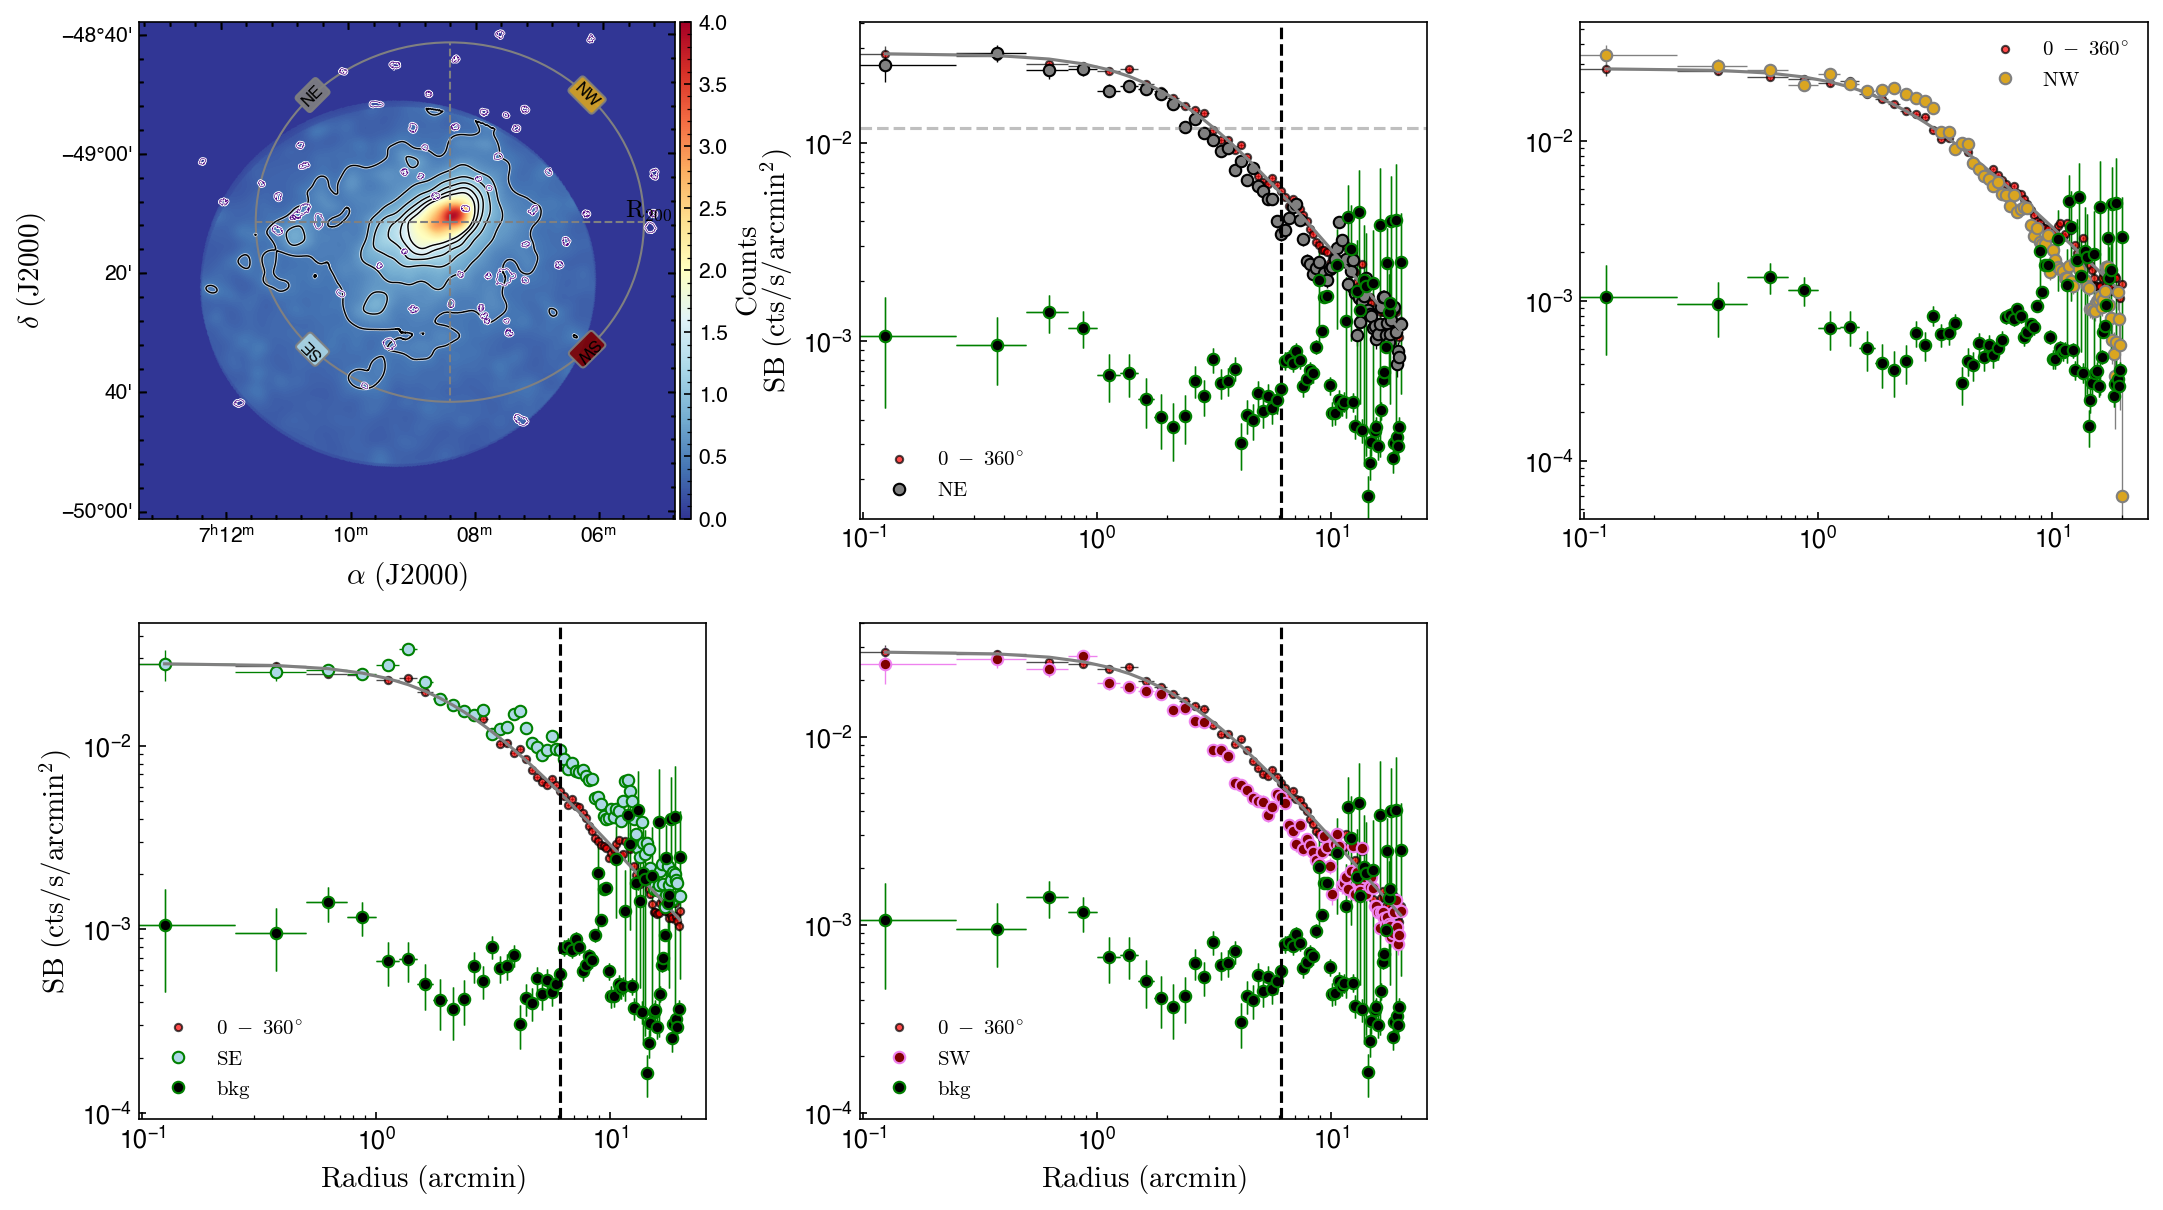

R200: 1.5 Mpc = 1809.6 arcsec = 452.4 pixels


In [319]:
import pylab as pl
import numpy as np
import pyproffit
from astropy.coordinates import Angle
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
from matplotlib.patches import Circle
from reproject import reproject_interp
from matplotlib.gridspec import GridSpec

# image_file = "data/full_eband/tm0_soft_band_8_23eV.fits" # photon image
# exposure_map_file = 'data/full_eband/tm0_nonvignetted_expmap.fits' # non-vignetted exposure map
# background_map_file = 'data/full_eband/tm0_pib_map.fits'               # particle induced background map

image_file = "data/full_eband/cheesemask_applied.fits"
exposure_map_file = 'data/full_eband/expmap_cheesemask.fits'
background_map_file = 'data/full_eband/pib_cheesemask.fits'

xray_hdu = fits.open('../analysis/data/full_eband/tm0_background.fits')[0]  # X-ray image (1250x1250)
xray_data = xray_hdu.data
xray_wcs = WCS(xray_hdu.header)

hi_hdu = fits.open('../analysis/data/full_eband/cluster_dilated_mom0.fits')[0]  # HI image (2600x2600)

hi_data = hi_hdu.data
hi_wcs = WCS(hi_hdu.header, naxis=2)

hi_reprojected, footprint = reproject_interp(
    (hi_data, hi_wcs),  # Input data and WCS
    xray_wcs,  # Target WCS (X-ray)
    shape_out=xray_data.shape  # Target shape (1250x1250)
)


dat = pyproffit.Data(
    imglink=image_file, 
    explink=exposure_map_file,
    bkglink=background_map_file
)

ra_str = "07h08m31.7s"
dec_str = "-49d12m52s"

ra_peak = "7h08m24.1908296"
dec_peak = "-49d11m47.0125448356"

ra = Angle(ra_peak, unit=u.hourangle)
dec = Angle(dec_peak, unit=u.deg)


dat.img[np.isnan(dat.img)] = 0.0

# Create profiles
# prof = pyproffit.Profile(data=dat, center_choice='peak', maxrad=70, binsize=30, binning='log')
# prof_ne = pyproffit.Profile(data=dat, center_choice='peak', maxrad=70, binsize=30, binning='log')
# prof_nw = pyproffit.Profile(data=dat, center_choice='peak', maxrad=70, binsize=30, binning='log')
# prof_se = pyproffit.Profile(data=dat, center_choice='peak', maxrad=70, binsize=30, binning='log')
# prof_sw = pyproffit.Profile(data=dat, center_choice='peak', maxrad=70, binsize=30, binning='log')

prof = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra.degree, center_dec=dec.degree, maxrad=20, binsize=15)
prof_ne = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra.degree, center_dec=dec.degree, maxrad=20, binsize=15)
prof_nw = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra.degree, center_dec=dec.degree, maxrad=20, binsize=15)
prof_se = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra.degree, center_dec=dec.degree, maxrad=20, binsize=15)
prof_sw = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra.degree, center_dec=dec.degree, maxrad=20, binsize=15)


print(prof.ellangle, prof.ellratio)

# Generate surface brightness profiles
prof.SBprofile(rotation_angle=0., ellipse_ratio=1, angle_low=prof.anglow, angle_high=prof.anghigh)
prof_se.SBprofile(rotation_angle=0, ellipse_ratio=1, angle_low=180., angle_high=270)
prof_ne.SBprofile(rotation_angle=0, ellipse_ratio=1, angle_low=90, angle_high=180)
prof_nw.SBprofile(rotation_angle=0, ellipse_ratio=1, angle_low=0., angle_high=90)
prof_sw.SBprofile(rotation_angle=0, ellipse_ratio=1, angle_low=270, angle_high=360)


ra_bkg = '7h10m47.2816827256'
dec_bkg = '-49d39m44.3988753069'


ra_bkg = Angle(ra_bkg, unit=u.hourangle)
dec_bkg = Angle(dec_bkg, unit=u.deg)

bkg = pyproffit.Profile(data=dat, center_choice='custom_fk5', center_ra=ra_bkg.degree, center_dec=dec_bkg.degree, maxrad=20, binsize=15) 

bkg.SBprofile(rotation_angle=0., ellipse_ratio=1, angle_low=bkg.anglow, angle_high=bkg.anghigh)
# model fitting - single beta

#prof_accounted = prof.account_for_bkg(bkg.profile[-1])
mod=pyproffit.Model(pyproffit.BetaModel)

#fitobj=pyproffit.Fitter(model=mod, profile=prof, beta=0.7, rc=2.,norm=-2,bkg=-4)
fitobj=pyproffit.Fitter(model=mod, method='cstat', profile=prof, beta=0.7, rc=2., norm=-2, bkg=-3, fitlow=0., fithigh=30.)
print(mod.params)
fitobj.Migrad()
model_values = mod.model(prof.bins, mod.params[0], mod.params[1], mod.params[2], mod.params[3])

# Load image data
with fits.open(image_file) as hdul:
    image_data = hdul[0].data
    wcs = WCS(hdul[0].header)

cheesemask = None  # Define this if you have a mask
if cheesemask is not None:
    masked_image = np.copy(image_data).astype(float)
    masked_image[~cheesemask] = np.nan
else:
    masked_image = image_data

# Center coordinates
ra_center = ra.degree
dec_center = dec.degree
radius = 452.4
max_radius = 452.4

center_coord = SkyCoord(ra_center * u.deg, dec_center * u.deg, frame='icrs')
center_x, center_y = wcs.world_to_pixel(center_coord)

# Create figure with 2x3 subplots (5 total: 1 image + 4 quadrants)
fig = pl.figure(figsize=(18, 8))

# First subplot: Image
ax1 = fig.add_subplot(2, 3, 1, projection=wcs)
im = ax1.imshow(xray_data, origin='lower', cmap='RdYlBu_r', vmin=0, vmax=4, aspect='auto')
ax1.contour(xray_data, levels=[0.45, 0.7, 0.95, 1.2, 1.45, 1.7], colors='w', linewidths=1.5, alpha=0.7)
ax1.contour(xray_data, levels=[0.45, 0.7, 0.95, 1.2, 1.45, 1.7], colors='k', linewidths=0.7)
# step 4: Overlay HI contours
levels=[1.5]
ax1.contour(hi_reprojected, levels=levels, colors='w', linewidths=1.2)
ax1.contour(hi_reprojected, levels=levels, colors='indigo', linewidths=.3)

max_radius = max(df['Outer_Radius_Pixels'].max() for df in profile_results.values())
radii = profile_results['NE']['Outer_Radius_Pixels']

for outer_r in radii:
    circle = Circle((center_x, center_y), outer_r, fill=False, edgecolor='grey', linestyle='-', linewidth=1)
ax1.add_patch(circle)

ax1.plot([center_x, center_x + max_radius], [center_y, center_y], color='grey', ls='--', linewidth=1)
ax1.plot([center_x, center_x - max_radius], [center_y, center_y], color='grey', ls='--', linewidth=1)
ax1.plot([center_x, center_x], [center_y, center_y + max_radius], color='grey', ls='--', linewidth=1)
ax1.plot([center_x, center_x], [center_y, center_y - max_radius], color='grey', ls='--', linewidth=1)

# Add quadrant labels on the diagonal lines
label_radius = max_radius  # Slightly beyond the circle

quadrants = {
    'NW': np.pi/4,     # 45 degrees
    'NE': 3*np.pi/4,   # 135 degrees
    'SE': 5*np.pi/4,   # 225 degrees
    'SW': 7*np.pi/4    # 315 degrees
}

quad_colors = {
    'NE': 'grey',
    'NW': 'goldenrod', 
    'SW': 'maroon', 
    'SE': 'lightblue'
}
quad_rotations = {
    'NW': 315,  # NE rotated at 315°
    'NE': 45,   # NW rotated at 45°
    'SE': 135,  # SW rotated at 135°
    'SW': 225   # SE rotated at 225°
}

for name, angle in quadrants.items():
    x = center_x + label_radius * np.cos(angle)
    y = center_y + label_radius * np.sin(angle)
    
    ax1.text(x, y, name, color='black', fontsize=8, rotation=quad_rotations[name],
                ha='center', va='center', fontweight='regular',
                bbox=dict(facecolor=quad_colors[name], edgecolor='grey', 
                        boxstyle='round, pad=0.2', alpha=0.9))
    
z = 0.042
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
d_A = cosmo.angular_diameter_distance(z).value  # in Mpc
r200_mpc = 1.5  # R200 in Mpc
theta_rad = r200_mpc / d_A  # angular size in radians
theta_arcsec = theta_rad * (180 / np.pi) * 3600  # convert to arcseconds
pixel_scale = 4  # arcseconds per pixel
r200_pixels = theta_arcsec / pixel_scale  # R200 in pixels

print(f"R200: {r200_mpc} Mpc = {theta_arcsec:.1f} arcsec = {r200_pixels:.1f} pixels")

ax1.text(center_x  + r200_pixels + 10, center_y, r"$\rm R_{200}$", color='k', 
            fontsize=12, ha='center', va='bottom')

ax1.set_xlabel(r'$\rm \alpha\ (J2000)$', fontsize=14)
ax1.set_ylabel(r'$\rm \delta\ (J2000)$', fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=10)


# Add colorbar for the image
cbar = fig.colorbar(im, ax=ax1, aspect=45, pad=0.009, fraction=0.046)
cbar.set_label(r'$\rm Counts$', fontsize=14)
cbar.ax.tick_params(labelsize=10)

# Second subplot: NE quadrant
ax2 = fig.add_subplot(2, 3, 2)
# Plot full profile for comparison
ax2.plot(prof.bins, prof.profile, color='red', ls='', marker='o', linewidth=0.85, ms=3.5, 
         markeredgecolor='k', label=r'$\rm 0\ -\ 360^{\circ}$', alpha=0.7)
ax2.errorbar(prof.bins, prof.profile, xerr=prof.ebins, yerr=prof.eprof, 
             fmt='none', color='k', zorder=1, elinewidth=0.65, alpha=0.7)
# Plot NE quadrant
ax2.plot(prof_ne.bins, prof_ne.profile, color='grey', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='k', label=r'$\rm NE$')
ax2.errorbar(prof_ne.bins, prof_ne.profile, xerr=prof_ne.ebins, yerr=prof_ne.eprof, 
             fmt='none', color='k', zorder=1, elinewidth=0.65)
ax2.plot(prof.bins, model_values, ls = '-', color = 'grey')


ax2.axvline(np.log(452.4), ls='--', color='k')
try:
    for i, row in quad_results.iterrows():
        sb = row['Surface_Brightness']
        if i > 2:
            ax2.axhline(sb, linestyle='--', color='grey', alpha=0.5)
except:
    pass

ax2.set_yscale('log')
ax2.set_xscale('log')
#ax2.set_xlim([0, 10])
ax2.legend(fontsize=10, frameon=False)
# ax2.set_xlabel(r'$\rm Radius\ (arcmin)$', fontsize=11)
ax2.set_ylabel(r'$\rm SB\ (cts/s/arcmin^2)$', fontsize=14)

ax2.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)
ax2.plot(bkg.bins, bkg.profile, color='k', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='g', label=r'$\rm bkg$')
ax2.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)

# Third subplot: NW quadrant
ax3 = fig.add_subplot(2, 3, 3)
# Plot full profile for comparison
ax3.plot(prof.bins, prof.profile, color='red', ls='', marker='o', linewidth=0.85, ms=3.5, 
         markeredgecolor='k', label=r'$\rm 0\ -\ 360^{\circ}$', alpha=0.7)
ax3.plot(prof.bins, model_values, ls = '-', color = 'grey')
#ax3.axhline(-1*mod.params[-1], ls = '--', color='grey')
ax3.errorbar(prof.bins, prof.profile, xerr=prof.ebins, yerr=prof.eprof, 
             fmt='none', color='k', zorder=1, elinewidth=0.65, alpha=0.7)
# Plot NW quadrant
ax3.plot(prof_nw.bins, prof_nw.profile, color='goldenrod', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='grey', label=r'$\rm NW$')
ax3.errorbar(prof_nw.bins, prof_nw.profile, xerr=prof_nw.ebins, yerr=prof_nw.eprof, 
             fmt='none', color='grey', zorder=1, elinewidth=0.65)

ax3.set_yscale('log')
ax3.set_xscale('log')
#ax3.set_xlim([0, 10])
ax3.legend(fontsize=10, frameon=False)

ax3.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)
ax3.plot(bkg.bins, bkg.profile, color='k', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='g', label=r'$\rm bkg$')
ax3.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)


# Fourth subplot: SE quadrant
ax4 = fig.add_subplot(2, 3, 4)
# Plot full profile for comparison
ax4.plot(prof.bins, prof.profile, color='red', ls='', marker='o', linewidth=0.85, ms=3.5, 
         markeredgecolor='k', label=r'$\rm 0\ -\ 360^{\circ}$', alpha=0.7)
ax4.errorbar(prof.bins, prof.profile, xerr=prof.ebins, yerr=prof.eprof, 
             fmt='none', color='k', zorder=1, elinewidth=0.65, alpha=0.7)
# Plot SE quadrant
ax4.plot(prof_se.bins, prof_se.profile, color='lightblue', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='g', label=r'$\rm SE$')
ax4.errorbar(prof_se.bins, prof_se.profile, xerr=prof_se.ebins, yerr=prof_se.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)
ax4.plot(prof.bins, model_values, ls = '-', color = 'grey')

ax4.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)
ax4.plot(bkg.bins, bkg.profile, color='k', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='g', label=r'$\rm bkg$')
ax4.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)

ax4.axvline(np.log(452.4), ls='--', color='k')
ax4.set_yscale('log')
ax4.set_xscale('log')
#ax4.set_xlim([0, 10])
ax4.legend(fontsize=10, frameon=False)
ax4.set_xlabel(r'$\rm Radius\ (arcmin)$', fontsize=14)
ax4.set_ylabel(r'$\rm SB\ (cts/s/arcmin^2)$', fontsize=14)

# fifth subplot: SW quadrant
ax5 = fig.add_subplot(2, 3, 5)
# plot full profile for comparison
ax5.plot(prof.bins, prof.profile, color='red', ls='', marker='o', linewidth=0.85, ms=3.5, 
         markeredgecolor='k', label=r'$\rm 0\ -\ 360^{\circ}$', alpha=0.7)
ax5.errorbar(prof.bins, prof.profile, xerr=prof.ebins, yerr=prof.eprof, 
             fmt='none', color='k', zorder=1, elinewidth=0.65, alpha=0.7)
# plot SW quadrant
ax5.plot(prof_sw.bins, prof_sw.profile, color='maroon', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='violet', label=r'$\rm SW$')
ax5.errorbar(prof_sw.bins, prof_sw.profile, xerr=prof_sw.ebins, yerr=prof_sw.eprof, 
             fmt='none', color='violet', zorder=1, elinewidth=0.65)
ax5.plot(prof.bins, model_values, ls = '-', color = 'grey')

ax5.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)
ax5.plot(bkg.bins, bkg.profile, color='k', ls='', marker='o', linewidth=0.85, ms=5.5,  
         markeredgecolor='g', label=r'$\rm bkg$')
ax5.errorbar(bkg.bins, bkg.profile, xerr=bkg.ebins, yerr=bkg.eprof, 
             fmt='none', color='g', zorder=1, elinewidth=0.65)


ax5.axvline(np.log(452.4), ls='--', color='k')
ax5.set_yscale('log')
ax5.set_xscale('log')
#ax5.set_xlim([0, 10])
ax5.legend(fontsize=10, frameon=False)
ax5.set_xlabel(r'$\rm Radius\ (arcmin)$', fontsize=14)
# ax5.set_ylabel(r'$\rm SB\ (cts/s/arcsec^2)$', fontsize=11)

# Adjust layout and save
pl.tight_layout()
pl.subplots_adjust(right=0.8 , top=1., wspace=0.27)
#pl.savefig('figures/pyproffit_surfbrightness_multipanel.pdf', format='pdf', dpi=150, bbox_inches='tight')
pl.show()

print(f"R200: {r200_mpc} Mpc = {theta_arcsec:.1f} arcsec = {r200_pixels:.1f} pixels")

In [20]:
import numpy as np
from astropy.wcs import WCS
from astropy.io import fits

hdu = fits.open('data/full_eband/tm0_soft_band_8_23eV.fits')[0]
wcs = WCS(hdu.header)

catalog = np.loadtxt('data/full_eband/sources_corrected.cat', usecols=(1, 2, 18))  # X, Y, FWHM

with open('data/full_eband/abell3408_masked.reg', 'w') as f:
    # Main cluster region
    f.write("fk5; circle(7:08:31.7000,-49:12:52.000,911.695\")\n\n")
    
    # Exclude point sources
    for x, y, fwhm in catalog:
        ra, dec = wcs.pixel_to_world_values(x, y)
        radius = max(15, fwhm * 1.5)  # Use 1.5×FWHM or 15" minimum
        f.write(f"-circle({ra:.6f}, {dec:.6f}, {radius:.1f}\")\n")

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58767.375556 from DATE-OBS.
Set MJD-END to 58767.957789 from DATE-END'. [astropy.wcs.wcs]
